# Эксперименты с текстовыми признаками краудфандинговых проектов

Ноутбук извлекает текстовые и численные признаки из описаний проектов Planeta.ru и прогоняет эконометрические + ML-модели с целевыми переменными `is_successful` (бинарная), `funding_bucket` (3 класса), `log_funding_ratio` (непрерывная) и two-part моделью.

**Структура:**
1. Конфиг (гиперпараметры, словари, пути)
2. Загрузка данных и сэмплирование
3. Чистка текста под каждую задачу
4. Лексические признаки: социальность, благодарность, коллективизм, уверенность
5. Численные признаки: упоминания денег, плотность чисел
6. Читаемость (Flesch / Fog / LIX)
7. RuBERT sentiment
8. LDA topic modeling
9. Визуализации (распределения, таргет vs фичи, корреляции)
10. Logit (бинарная целевая)
11. Probit (альтернатива Logit)
12. ML-модели с разными наборами признаков + CV
13. SHAP
14. Категориальный таргет `funding_bucket` (<0.5 / 0.5–1 / ≥1)
15. Multinomial Logit
16. Ordered Logit / Ordered Probit
17. Явный train/test split (80/20)
18. GAM / сплайны (LogisticGAM + patsy.bs)
19. Interaction terms
20. Квантильная регрессия
21. Two-part / Hurdle (селекция + интенсивность, плюс подгруппы: провалы → приближение к 1; успешные → overfunding)
22. Year fixed effects (OLS + Logit) + F-test / Wald / LR на совместную значимость


## 1. Импорты

In [13]:
import os
import re
import html
import warnings
from collections import Counter
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

try:
    import pymorphy3 as _pymorphy
except ImportError:
    import pymorphy2 as _pymorphy
morph = _pymorphy.MorphAnalyzer()

import nltk
for pkg in ("punkt", "punkt_tab"):
    try:
        nltk.data.find(f"tokenizers/{pkg}")
    except LookupError:
        nltk.download(pkg, quiet=True)


## 2. Конфигурация

Все параметры, которые обычно правят — в одном месте.

- `SAMPLE_SIZE` — сколько строк брать из входного файла (для скорости).
- `INPUT_FILE` — уже очищенный файл со всеми исходными колонками.
- `TEXT_COL` — основная текстовая колонка с описанием проекта.
- `RANDOM_STATE` — глобальный сид для воспроизводимости.


In [14]:
# ───── пути и входные данные ─────
INPUT_FILE = "projects_planeta_cleaned.xlsx"
TEXT_COL = "description.text"
TARGET_COL = "is_successful"
RANDOM_STATE = 42

# ───── сэмплирование ─────
SAMPLE_SIZE = None          # сколько строк брать (None = всё)
SAMPLE_STRATIFY = True     # стратифицированный сэмпл по is_successful

# ───── LDA ─────
LDA_NUM_TOPICS = 5
LDA_PASSES = 10
LDA_MIN_WORD_LEN = 3

# ───── RuBERT sentiment ─────
RUBERT_MODEL = "blanchefort/rubert-base-cased-sentiment"
RUBERT_MAX_SENTS = 200
RUBERT_BATCH = 16
RUBERT_MAX_LEN = 512

# ───── визуализации ─────
FIG_DIR = "figures_texts_experiments"
os.makedirs(FIG_DIR, exist_ok=True)

# ───── ML ─────
CV_FOLDS = 5
TEST_THRESHOLD = 0.5


## 3. Словари для лексических признаков

Все списки — в нормальной форме (лемматизатор приведёт текст к этому виду). Исключение — местоимения `WE_WORDS` / `I_WORDS`: ищем все словоформы напрямую.


In [15]:
SOCIAL_WORDS = {
    # "мы/наш/вы/ваш" и слишком общее "человек" убраны:
    # первые дублируют WE_WORDS (двойной счёт коллективности),
    # "человек/сеть/круг/близкий/сбор/вклад/бэкер" — слишком частотные
    # или полисемичные, давали ложные срабатывания.
    "команда", "сообщество", "группа", "коллектив", "союз", "объединение",
    "ассоциация", "организация", "клуб", "движение",
    "друг", "подруга", "товарищ", "коллега", "партнёр",
    "единомышленник", "соратник", "сторонник", "участник", "волонтёр",
    "помощник", "помощница", "поддержка", "спонсор", "меценат", "инвестор",
    "семья", "семейный", "родитель", "ребёнок", "родственник",
    "общество", "народ", "гражданин", "население",
    "общественный", "социальный", "публичный", "совместный", "коллективный",
    "вместе", "совместно", "сообща",
    "совместить", "объединить", "объединять", "объединиться", "объединяться",
    "присоединиться", "присоединяться",
    "поддержать", "поддерживать", "помочь", "помогать", "участвовать",
    "сотрудничать", "сотрудничество", "взаимодействие", "взаимопомощь",
    "краудфандинг", "донор", "донация", "пожертвование",
    "взнос", "финансирование", "содействие",
}

GRATITUDE_ROOTS = [
    r"спасиб\w*",
    r"благодар\w*",
    r"признат(?:елен|ельн\w*)",
    r"от всего сердца",
    r"низкий поклон",
    r"цени[мт]\w*",
]

WE_WORDS = {
    "мы", "нас", "нам", "нами",
    "наш", "наша", "наше", "наши",
    "нашего", "нашей", "нашему", "нашим", "нашими", "нашем",
    "наших", "нашу",
}
I_WORDS = {
    "я", "меня", "мне", "мной", "мною",
    "мой", "моя", "моё", "мои",
    "моего", "моей", "моему", "моим", "моими", "моём",
    "моих", "мою",
}

CERTAINTY_WORDS = {
    "точно", "конечно", "обязательно", "гарантированно",
    "безусловно", "несомненно", "определённо", "достоверно",
    "однозначно", "непременно", "неизбежно", "известно", "ясно",
    "бесспорно", "очевидно",
    "бесспорный", "непреложный", "очевидный", "уверенный",
    "убеждённый", "выполнимый",
    "безусловный", "несомненный", "достоверный",
    "гарантировать", "доказать", "проверить", "подтвердить",
    "реализовать", "выполнить", "уверить",
    "факт", "гарантия", "уверенность",
}
UNCERTAINTY_WORDS = {
    # убраны: "если" (союз), "мочь/думать/хотеть/хотеться" (слишком частотные),
    # "планировать/планироваться" (в краудфандинге это нормальное заявление,
    # а не маркер неуверенности).
    "возможно", "наверное", "наверно", "вероятно",
    "пожалуй", "предположительно",
    "казаться", "надеяться",
    "стараться", "постараться", "попробовать",
    "рассчитывать", "ожидать", "предполагать",
    "вероятность", "шанс", "риск", "неопределённость",
}

# Базовый список стопов (≈ nltk russian) + добавки под наш домен.
# Без обращения к nltk.download → работает офлайн.
RU_STOPWORDS = {
    # местоимения
    "я", "ты", "он", "она", "оно", "мы", "вы", "они",
    "меня", "мне", "мной", "мною", "мной",
    "тебя", "тебе", "тобой", "тобою",
    "его", "ему", "им", "нём", "нем",
    "её", "ее", "ей", "ею",
    "нас", "нам", "нами",
    "вас", "вам", "вами",
    "их", "ими", "них",
    "себя", "себе", "собой", "собою",
    "мой", "моя", "моё", "мое", "мои",
    "наш", "наша", "наше", "наши",
    "твой", "твоя", "твоё", "твое", "твои",
    "ваш", "ваша", "ваше", "ваши",
    "свой", "своя", "своё", "свое", "свои",
    "этот", "эта", "это", "эти",
    "тот", "та", "то", "те",
    "такой", "такая", "такое", "такие",
    "сам", "сама", "само", "сами",
    "весь", "вся", "всё", "все",
    "кто", "что", "кого", "чего", "кому", "чему", "кем", "чем",
    "который", "которая", "которое", "которые",
    "какой", "какая", "какое", "какие",
    "чей", "чья", "чьё", "чьи",
    # предлоги
    "в", "во", "на", "по", "за", "из", "к", "ко", "у", "о", "об", "обо",
    "от", "до", "для", "над", "под", "при", "про", "через", "без",
    "около", "между", "перед", "после", "среди",
    # союзы и частицы
    "и", "а", "но", "или", "либо", "ни", "да", "же", "ведь", "хоть",
    "что", "чтобы", "если", "когда", "пока", "так", "как", "будто",
    "ли", "бы", "ну", "то", "уж", "вот", "вон", "разве",
    # частотные наречия и связки
    "не", "нет", "уже", "ещё", "еще", "только", "очень", "тоже", "также",
    "иногда", "всегда", "никогда", "сегодня", "вчера", "завтра",
    "здесь", "там", "тут", "туда", "сюда", "оттуда", "теперь",
    "можно", "нужно", "надо", "пусть",
    # связки/глагол быть
    "быть", "был", "была", "было", "были", "есть", "будет",
    "будут", "буду", "будешь", "будем", "будете",
    # домашние добавки
    "год", "году", "годов", "лет",
    "раз", "разы",
    "это", "этого", "этому", "этим", "этом",
}

GRATITUDE_PATTERN = re.compile("|".join(GRATITUDE_ROOTS),
                               flags=re.IGNORECASE | re.UNICODE)

print("словари загружены:")
print(f"  SOCIAL_WORDS        : {len(SOCIAL_WORDS)}")
print(f"  GRATITUDE_ROOTS     : {len(GRATITUDE_ROOTS)}")
print(f"  WE_WORDS / I_WORDS  : {len(WE_WORDS)} / {len(I_WORDS)}")
print(f"  CERTAINTY_WORDS     : {len(CERTAINTY_WORDS)}")
print(f"  UNCERTAINTY_WORDS   : {len(UNCERTAINTY_WORDS)}")
print(f"  RU_STOPWORDS        : {len(RU_STOPWORDS)}")


словари загружены:
  SOCIAL_WORDS        : 66
  GRATITUDE_ROOTS     : 6
  WE_WORDS / I_WORDS  : 16 / 17
  CERTAINTY_WORDS     : 34
  UNCERTAINTY_WORDS   : 18
  RU_STOPWORDS        : 199


## 4. Загрузка данных

Берём сэмпл `SAMPLE_SIZE` строк (стратифицированный по целевой переменной, если возможно).


In [4]:
df_full = pd.read_excel(INPUT_FILE)
print(f"полный датасет: {df_full.shape}")

# убираем строки без target для стратификации
if TARGET_COL in df_full.columns:
    n_missing = df_full[TARGET_COL].isna().sum()
    if n_missing > 0:
        print(f"Удаляем строки с NaN в {TARGET_COL}: {n_missing}")
        df_full = df_full[df_full[TARGET_COL].notna()].copy()

print(f"после удаления NaN в target: {df_full.shape}")

# сэмплирование
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df_full):
    if SAMPLE_STRATIFY and TARGET_COL in df_full.columns:
        from sklearn.model_selection import train_test_split
        _, df = train_test_split(
            df_full,
            test_size=SAMPLE_SIZE,
            stratify=df_full[TARGET_COL],
            random_state=RANDOM_STATE,
        )
    else:
        df = df_full.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
    df = df.reset_index(drop=True)
else:
    df = df_full.reset_index(drop=True)

print(f"рабочий сэмпл   : {df.shape}")
print(f"is_successful   : {df[TARGET_COL].value_counts(dropna=False).to_dict()}")
df.head(3)



полный датасет: (3192, 40)
после удаления NaN в target: (3192, 40)
рабочий сэмпл   : (3192, 40)
is_successful   : {0: 1622, 1: 1570}


,project_key,sourceUrl,card.title,card.subtitle,card.collectedAmount.value,card.targetAmount.value,card.daysToFinish,card.startAt,card.finishAt,card.region,card.mainCategory.tagName,card.author.id,card.author.campaignsAmount,card.links.vk_url,card.links.telegram_url,card.links.author_site_url,description.text,counts.newsCount,counts.commentsCount,counts.participantsCount,counts.purchasesCount,meta.description,rewards.totalRewards,image_count,video_count,reward_count,external_link_count,funding_ratio,is_successful,campaign_duration_days,title_len_chars,subtitle_len_chars,description_len_chars,meta_description_len_chars,title_word_count,subtitle_word_count,description_word_count,meta_description_word_count,description_has_link_word,category_grouped
0,100062,https://planeta.ru/campaigns/100062,Выездная служба паллиативной помощи,Помогите Насте жить максимально полноценной жи...,227022,222236,0,2018-12-03 11:02:23,2018-12-24 20:59:59,Москва и Московская обл.,Благотворительность,648045,13,https://vk.com/children_hospice,https://t.me/mayak_help,https://mayak.help,Насте почти 15 лет. Она играет на гавайской ги...,2,1,145,150,Помогите Насте жить максимально полноценной жи...,9,17,0,9,69,1.021536,1,21,35,74,2625,74,4,11,396,11,0,Благотворительность
1,100105,https://planeta.ru/campaigns/100105,Жизнь бездомных кошек в подвалах домов,Планируется отловить из подвалов многоквартрны...,26350,357120,0,2021-02-04 10:44:51,2021-12-01 20:59:59,Томская обл.,Благотворительность,893287,1,NaN,NaN,NaN,Проблема существования бездомных животных в го...,0,0,43,82,Планируется отловить из подвалов многоквартрны...,3,20,1,3,40,0.073785,0,300,38,116,3809,116,6,15,494,15,0,Благотворительность
2,100205,https://planeta.ru/campaigns/100205,Издание тиража фотоальбома «Рок 80-90-гг.»,"Уникальные фотографии, сделанные на рок концер...",170631,230000,0,2019-02-07 08:00:00,2019-05-12 20:59:59,Москва и Московская обл.,Дизайн и фотография,893758,1,NaN,NaN,NaN,"Меня зовут Алексей Кузнецов, всю свою сознател...",11,26,71,111,"Уникальные фотографии, сделанные на рок концер...",16,49,1,16,110,0.741874,0,94,42,172,5410,172,5,21,749,21,0,"Творческие (кино, театр, дизайн)"


## 5. Чистка текста

Для каждой задачи — своя чистка. Не используем одну универсальную функцию, чтобы не терять знаки, нужные для читаемости, и не вносить мусор в словарный матчинг.

| Цель                     | Что оставить              |
|--------------------------|---------------------------|
| LIWC-подобные признаки   | только буквы              |
| Читаемость               | пунктуация + цифры        |
| RuBERT                   | всё (кроме HTML)          |
| LDA                      | только буквы              |


In [5]:
def clean_text_for_liwc(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_text_for_readability(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = text.replace("\u00a0", " ")
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_text_for_rubert(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_text_for_lda(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^а-яёА-ЯЁa-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["clean_text"] = df[TEXT_COL].apply(clean_text_for_rubert)
df["clean_text"].str.len().describe().round(1)


count     3192.0
mean      3341.5
std       2056.9
min        506.0
25%       1964.8
50%       2826.0
75%       4094.5
max      21452.0
Name: clean_text, dtype: float64

## 6. Токенизация, лемматизация, разбивка на предложения

In [6]:
def tokenize(text: str) -> list[str]:
    if not isinstance(text, str) or not text.strip():
        return []
    return re.findall(r"[а-яёА-ЯЁa-zA-Z]+", text)


def lemmatize_tokens(tokens: list[str]) -> list[str]:
    return [morph.parse(t)[0].normal_form for t in tokens]


def split_sentences(text: str) -> list[str]:
    if not isinstance(text, str) or not text.strip():
        return []
    try:
        return nltk.sent_tokenize(text, language="russian")
    except Exception:
        return re.split(r"[.!?]+", text)


def count_syllables_ru(word: str) -> int:
    vowels = "аеёиоуыэюяАЕЁИОУЫЭЮЯ"
    return sum(1 for ch in word if ch in vowels)


## 7. Лексические признаки: социальность, благодарность, коллективизм, уверенность

Все доли нормируются либо к числу лемм, либо к числу токенов — это единый знаменатель, чтобы коэффициенты регрессий были сопоставимы.


In [7]:
def compute_social_score(text: str) -> float:
    tokens = tokenize(text)
    if not tokens:
        return 0.0
    lemmas = lemmatize_tokens(tokens)
    return sum(1 for l in lemmas if l in SOCIAL_WORDS) / len(lemmas)


def compute_gratitude(text: str) -> dict:
    if not isinstance(text, str):
        return {"gratitude_score": 0.0, "has_gratitude": 0}
    matches = GRATITUDE_PATTERN.findall(text)
    tokens = tokenize(text)
    n = len(tokens) if tokens else 1
    return {
        "gratitude_score": len(matches) / n,
        "has_gratitude": int(len(matches) > 0),
    }


def compute_collectivism(text: str) -> dict:
    tokens = tokenize(text)
    if not tokens:
        return {"we_count": 0, "i_count": 0,
                "we_ratio": 0.0, "i_ratio": 0.0, "we_vs_i": 0.0}
    # в текстах ё часто пишут как е → нормализуем при сравнении
    lowered = [t.lower().replace("ё", "е") for t in tokens]
    we_set = {w.replace("ё", "е") for w in WE_WORDS}
    i_set = {w.replace("ё", "е") for w in I_WORDS}
    we = sum(1 for t in lowered if t in we_set)
    i_ = sum(1 for t in lowered if t in i_set)
    n = len(tokens)
    return {
        "we_count": we, "i_count": i_,
        "we_ratio": we / n, "i_ratio": i_ / n,
        "we_vs_i": we / (i_ + 1),
    }


def compute_certainty(text: str) -> dict:
    tokens = tokenize(text)
    if not tokens:
        return {"certainty_score": 0.0, "uncertainty_score": 0.0}
    lemmas = lemmatize_tokens(tokens)
    n = len(lemmas)
    return {
        "certainty_score":   sum(1 for l in lemmas if l in CERTAINTY_WORDS) / n,
        "uncertainty_score": sum(1 for l in lemmas if l in UNCERTAINTY_WORDS) / n,
    }


## 8. Численные признаки + читаемость

- **Денежные упоминания / плотность чисел** — маркер конкретности: проект, обещающий «500 книг за ₽50 000», конкретнее абстрактного «сделать много добра».
- **Читаемость** — русскоязычная адаптация Flesch / Gunning Fog / LIX. `readability_avg` = `flesch - fog - lix` (инвертируем FOG/LIX, чтобы всё было в направлении «выше = проще»).
Использую только FOG (литература)

In [8]:
MONEY_PATTERN = re.compile(
    r"\d[\d\s,.]*\s*(?:руб|рублей|р\.|₽|тыс|тысяч|млн|миллион|копейк)",
    re.IGNORECASE,
)
NUMBERS_PATTERN = re.compile(r"\b\d+(?:[.,]\d+)?\b")


def compute_numeric_features(text: str) -> dict:
    if not isinstance(text, str):
        return {"money_mentions": 0, "number_density": 0.0, "has_specific_sum": 0}
    tokens = tokenize(text)
    n_tok = max(len(tokens), 1)
    money = len(MONEY_PATTERN.findall(text))
    nums = len(NUMBERS_PATTERN.findall(text))
    return {
        "money_mentions": money,
        "number_density": nums / n_tok,
        "has_specific_sum": int(bool(MONEY_PATTERN.search(text))),
    }


def compute_readability(text: str) -> dict:
    if not isinstance(text, str) or not text.strip():
        return {"readability_flesch": np.nan,
                "readability_fog": np.nan,
                "readability_lix": np.nan}
    sents = [s for s in split_sentences(text) if s.strip()]
    n_sent = max(len(sents), 1)
    toks = re.findall(r"[а-яёА-ЯЁa-zA-Z]+", text)
    n_w = len(toks)
    if n_w == 0:
        return {"readability_flesch": np.nan,
                "readability_fog": np.nan,
                "readability_lix": np.nan}
    n_syl = sum(count_syllables_ru(w) for w in toks)
    n_cx = sum(1 for w in toks if count_syllables_ru(w) >= 3)
    n_long = sum(1 for w in toks if len(w) > 6)
    asl = n_w / n_sent
    asw = n_syl / n_w
    return {
        "readability_flesch": round(206.835 - 1.015 * asl - 84.6 * asw, 4),
        "readability_fog":    round(0.4 * (asl + 100 * n_cx / n_w), 4),
        "readability_lix":    round(asl + 100 * n_long / n_w, 4),
    }


## 9. Извлекаем все «быстрые» признаки

In [9]:
def extract_fast_features(df: pd.DataFrame) -> pd.DataFrame:
    from tqdm import tqdm

    df = df.copy()
    rows = []
    for orig in tqdm(df[TEXT_COL],
                     total=len(df),
                     desc="[Features] извлечение признаков",
                     unit="текст",
                     ncols=80,
                     colour="cyan"):
        row = {}
        t_liwc = clean_text_for_liwc(orig)
        row["social_score"] = compute_social_score(t_liwc)
        row.update(compute_gratitude(t_liwc))
        row.update(compute_collectivism(t_liwc))
        row.update(compute_certainty(t_liwc))
        row.update(compute_numeric_features(orig))
        row.update(compute_readability(clean_text_for_readability(orig)))
        rows.append(row)

    feats = pd.DataFrame(rows, index=df.index)
    out = pd.concat([df, feats], axis=1)

    # # --- нормализованное среднее по z-score ---
    # readability_cols = ["readability_flesch", "readability_fog", "readability_lix"]
    # normed = out[readability_cols].copy()
    # for col in tqdm(readability_cols, ...):
    #     mu, sigma = normed[col].mean(), normed[col].std()
    #     normed[col] = (normed[col] - mu) / max(sigma, 1e-9)
    # out["readability_avg"] = (
    #     normed["readability_flesch"]
    #     - normed["readability_fog"]
    #     - normed["readability_lix"]
    # ) / 3.0

    # убираем flesch и lix, оставляем только fog
    out = out.drop(columns=["readability_flesch", "readability_lix"], errors="ignore")

    return out


# --- только fog ---
READABILITY_COLS = [
    # "readability_flesch",
    "readability_fog",
    # "readability_lix",
    # "readability_avg",
]

FAST_FEATURE_COLS = [
    "social_score",
    "gratitude_score", "has_gratitude",
    "we_count", "i_count", "we_ratio", "i_ratio", "we_vs_i",
    "certainty_score", "uncertainty_score",
    "money_mentions", "number_density", "has_specific_sum",
    *READABILITY_COLS,
]

# --- сброс и пересчёт ---
df = df.drop(columns=[c for c in FAST_FEATURE_COLS if c in df.columns])
df = extract_fast_features(df)

# --- проверка ---
print(f"Все столбцы присутствуют: "
      f"{all(c in df.columns for c in FAST_FEATURE_COLS)}")
print(f"Столбцы читаемости: {READABILITY_COLS}")

df[FAST_FEATURE_COLS].describe().T[["mean", "std", "min", "max"]].round(4)


[Features] извлечение признаков: 100%|███| 3192/3192 [05:14<00:00, 10.13текст/s]


Все столбцы присутствуют: True
Столбцы читаемости: ['readability_fog']


,mean,std,min,max
social_score,0.0283,0.0209,0.0000,0.1625
gratitude_score,0.0020,0.0029,0.0000,0.0255
has_gratitude,0.4906,0.5000,0.0000,1.0000
we_count,10.6432,9.7507,0.0000,77.0000
i_count,3.8622,8.1421,0.0000,86.0000
we_ratio,0.0246,0.0194,0.0000,0.1060
i_ratio,0.0077,0.0143,0.0000,0.0863
we_vs_i,7.5401,8.6832,0.0000,63.0000
certainty_score,0.0021,0.0027,0.0000,0.0236
uncertainty_score,0.0020,0.0027,0.0000,0.0171


## 10. RuBERT sentiment

Предобученная модель `blanchefort/rubert-base-cased-sentiment` даёт `positive / negative / neutral` по каждому предложению; агрегируем средним по документу. Дропаем `rubert_neutral` для избежания идеальной коллинеарности (три вероятности суммируются в 1).


In [10]:
def add_rubert_sentiment(df: pd.DataFrame, text_col: str = "clean_text") -> pd.DataFrame:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    import torch
    from tqdm import tqdm

    print(f"[RuBERT] загружаю {RUBERT_MODEL}...")
    tok = AutoTokenizer.from_pretrained(RUBERT_MODEL)
    model = AutoModelForSequenceClassification.from_pretrained(RUBERT_MODEL)
    model.eval()

    id2label = model.config.id2label
    label_map = {v.upper(): k for k, v in id2label.items()}

    def score_text(text: str) -> dict:
        if not isinstance(text, str) or not text.strip():
            return {"rubert_positive": np.nan,
                    "rubert_negative": np.nan,
                    "rubert_neutral":  np.nan}
        try:
            sents = nltk.sent_tokenize(text, language="russian")
        except Exception:
            sents = [text]
        sents = [s[:RUBERT_MAX_LEN] for s in sents if s.strip()][:RUBERT_MAX_SENTS]
        if not sents:
            return {"rubert_positive": np.nan,
                    "rubert_negative": np.nan,
                    "rubert_neutral":  np.nan}
        probs_acc = []
        with torch.no_grad():
            for i in range(0, len(sents), RUBERT_BATCH):
                batch = sents[i:i + RUBERT_BATCH]
                enc = tok(batch, padding=True, truncation=True,
                          max_length=RUBERT_MAX_LEN, return_tensors="pt")
                logits = model(**enc).logits
                probs = torch.softmax(logits, dim=-1).cpu().numpy()
                probs_acc.append(probs)
        probs = np.vstack(probs_acc).mean(axis=0)
        return {
            "rubert_positive": float(probs[label_map["POSITIVE"]]),
            "rubert_negative": float(probs[label_map["NEGATIVE"]]),
            "rubert_neutral":  float(probs[label_map["NEUTRAL"]]),
        }

    texts = df[text_col].tolist()
    scores = []

    for t in tqdm(texts,
                  total=len(texts),
                  desc="[RuBERT] обработка текстов",
                  unit="текст",
                  ncols=80,
                  colour="green"):
        scores.append(score_text(t))

    return pd.concat([df, pd.DataFrame(scores, index=df.index)], axis=1)


df = df.drop(columns=[c for c in ("rubert_positive", "rubert_negative", "rubert_neutral")
                      if c in df.columns])
df = add_rubert_sentiment(df)
df = df.drop(columns=["rubert_neutral"], errors="ignore")
df[["rubert_positive", "rubert_negative"]].describe().round(4)


[RuBERT] загружаю blanchefort/rubert-base-cased-sentiment...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5855.08it/s]
BertForSequenceClassification LOAD REPORT from: blanchefort/rubert-base-cased-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[RuBERT] обработка текстов: 100%|████████| 3192/3192 [49:10<00:00,  1.08текст/s]


,rubert_positive,rubert_negative
count,3192.0000,3192.0000
mean,0.2797,0.1526
std,0.0929,0.0733
min,0.1057,0.0177
25%,0.2124,0.0993
50%,0.2659,0.1454
75%,0.3308,0.1982
max,0.7096,0.4568


In [11]:
df.to_excel('planeta_projects_with_features.xlsx', index=False)

## 11. LDA topic modeling

Строим распределение документов по темам. Фиксированное `LDA_NUM_TOPICS`; дропаем последнюю тему, чтобы вероятности не суммировались в 1.


In [12]:
# def add_lda_topics(df: pd.DataFrame, text_col: str = "clean_text",
#                    num_topics: int = LDA_NUM_TOPICS) -> pd.DataFrame:
#     from gensim.corpora import Dictionary
#     from gensim.models import LdaModel
#     from tqdm import tqdm

#     # --- токенизация и лемматизация ---
#     docs = []
#     for t in tqdm(df[text_col],
#                   total=len(df),
#                   desc="[LDA] токенизация",
#                   unit="текст",
#                   ncols=80,
#                   colour="blue"):
#         t_clean = clean_text_for_lda(t)
#         toks = tokenize(t_clean)
#         if not toks:
#             docs.append([])
#             continue
#         lemmas = lemmatize_tokens([w.lower() for w in toks])
#         lemmas = [w for w in lemmas if len(w) > LDA_MIN_WORD_LEN and w not in RU_STOPWORDS]
#         docs.append(lemmas)

#     if all(len(d) == 0 for d in docs):
#         print("[LDA] пустой корпус, пропускаю")
#         return df

#     dictionary = Dictionary(docs)
#     if len(docs) > 30:
#         dictionary.filter_extremes(no_below=2, no_above=0.9)
#     corpus = [dictionary.doc2bow(d) for d in docs]

#     print(f"[LDA] обучаю LDA (K={num_topics}) на {len(docs)} документах...")
#     lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics,
#                    passes=LDA_PASSES, random_state=RANDOM_STATE)

#     # --- извлечение тем ---
#     mat = np.zeros((len(docs), num_topics))
#     for i, bow in enumerate(tqdm(corpus,
#                                  total=len(corpus),
#                                  desc="[LDA] извлечение тем",
#                                  unit="doc",
#                                  ncols=80,
#                                  colour="green")):
#         for tid, p in lda.get_document_topics(bow, minimum_probability=0.0):
#             mat[i, tid] = p

#     tdf = pd.DataFrame(mat, columns=[f"topic_{i}" for i in range(num_topics)],
#                        index=df.index)

#     # --- топ-слова ---
#     print("[LDA] топ-слова по темам:")
#     for i in tqdm(range(num_topics),
#                   total=num_topics,
#                   desc="[LDA] топ-слова",
#                   unit="тема",
#                   ncols=80,
#                   colour="yellow"):
#         top = [w for w, _ in lda.show_topic(i, topn=8)]
#         tqdm.write(f"  topic_{i}: {', '.join(top)}")

#     return pd.concat([df, tdf], axis=1)


# df = df.drop(columns=[c for c in df.columns if c.startswith("topic_")])
# df = add_lda_topics(df)
# last_topic = f"topic_{LDA_NUM_TOPICS - 1}"
# df = df.drop(columns=[last_topic], errors="ignore")
# [c for c in df.columns if c.startswith("topic_")]


In [13]:
# # ═══════════════════════════════════════════════════════════════════════════════
# # 11. LDA topic modeling — multi-seed подбор K + стабильность
# # ═══════════════════════════════════════════════════════════════════════════════
# #
# # Что изменено vs прошлой версии (ячейка 23):
# #   • Подбор K ∈ k_range через c_v coherence по нескольким сидам — берём медиану
# #   • Выбор K по «плато»: наименьший K, чей median_cv ≥ 0.97 * max_median_cv
# #     (так получаем интерпретируемую сжатую модель вместо пика шума)
# #   • Жёсткая фиксация np.random.seed перед каждым фитом → воспроизводимость
# #   • В конце печатаются top-15 слов по каждому топику — для ручного именования
# #   • ПОСЛЕДНИЙ топик НЕ дропается автоматически: выбираешь вручную,
# #     посмотрев на топ-слова (см. закомментированную строку в конце)

# from gensim.corpora import Dictionary
# from gensim.models import LdaModel, CoherenceModel
# from gensim.models.phrases import Phrases, Phraser


# def _lda_preprocess(texts, use_ngrams: bool = True, verbose: bool = True):
#     """Токенизация + лемматизация + биграммы/триграммы → list of list of lemmas."""
#     docs = []
#     for t in tqdm(texts, desc="[LDA] препроцессинг", ncols=80, colour="blue"):
#         t_clean = clean_text_for_lda(t)
#         toks = tokenize(t_clean)
#         if not toks:
#             docs.append([])
#             continue
#         lemmas = lemmatize_tokens([w.lower() for w in toks])
#         lemmas = [
#             w for w in lemmas
#             if len(w) > LDA_MIN_WORD_LEN
#             and w not in RU_STOPWORDS
#             and not w.isdigit()
#         ]
#         docs.append(lemmas)

#     if use_ngrams and len(docs) > 10:
#         if verbose:
#             print("[LDA] строю биграммы и триграммы...")
#         bigram_mod = Phraser(Phrases(docs, min_count=3, threshold=8))
#         trigram_mod = Phraser(Phrases(bigram_mod[docs], min_count=3, threshold=8))
#         docs = [trigram_mod[bigram_mod[d]] for d in docs]
#         if verbose:
#             top_ngrams = Counter(
#                 w for d in docs for w in d if "_" in w
#             ).most_common(15)
#             print(f"[LDA] топ биграммы/триграммы: {[w for w, _ in top_ngrams]}")

#     return docs


# def _build_dictionary_corpus(docs, min_docs_for_filter: int = 30):
#     """Строит gensim Dictionary + corpus (BoW), фильтрует edge-частоты."""
#     dictionary = Dictionary(docs)
#     print(f"[LDA] словарь до фильтрации: {len(dictionary)} слов")

#     if len(docs) >= min_docs_for_filter:
#         dictionary.filter_extremes(no_below=3, no_above=0.85, keep_n=50_000)
#         short_ids = [
#             dictionary.token2id[t]
#             for t in list(dictionary.token2id.keys())
#             if len(t) <= 2
#         ]
#         if short_ids:
#             dictionary.filter_tokens(bad_ids=short_ids)
#         dictionary.compactify()

#     print(f"[LDA] словарь после фильтрации: {len(dictionary)} слов")
#     corpus = [dictionary.doc2bow(d) for d in docs]
#     return dictionary, corpus


# def _fit_lda(corpus, dictionary, K: int, seed: int,
#              passes: int = 20, iterations: int = 400):
#     """LDA с фиксированным seed: np.random.seed + random_state у модели."""
#     np.random.seed(seed)
#     return LdaModel(
#         corpus=corpus,
#         id2word=dictionary,
#         num_topics=K,
#         passes=passes,
#         iterations=iterations,
#         alpha="asymmetric",
#         eta="auto",
#         random_state=seed,
#         minimum_probability=0.01,
#     )


# def _coherence(lda, docs, dictionary, metric: str = "c_v") -> float:
#     try:
#         cm = CoherenceModel(
#             model=lda, texts=docs, dictionary=dictionary, coherence=metric
#         )
#         return float(cm.get_coherence())
#     except Exception as e:
#         print(f"[LDA] coherence fail: {e}")
#         return float("nan")


# def select_k_multiseed(corpus, dictionary, docs,
#                        k_range=range(3, 9),
#                        n_seeds: int = 3,
#                        plateau_ratio: float = 0.97,
#                        search_passes: int = 10,
#                        search_iterations: int = 200):
#     """
#     Для каждого K обучает n_seeds моделей с разными сидами, считает c_v,
#     берёт медиану. Возвращает (таблица результатов, best_K).

#     best_K = наименьший K, чей median_cv ≥ plateau_ratio · max(median_cv).
#     Даёт компактную интерпретируемую модель вместо максимума на шуме.
#     """
#     rows = []
#     print(
#         f"[LDA] подбор K ∈ {list(k_range)} × {n_seeds} сидов "
#         f"(passes={search_passes}):"
#     )
#     for K in k_range:
#         scores = []
#         for seed in range(RANDOM_STATE, RANDOM_STATE + n_seeds):
#             lda = _fit_lda(
#                 corpus, dictionary, K, seed,
#                 passes=search_passes, iterations=search_iterations,
#             )
#             cv = _coherence(lda, docs, dictionary, "c_v")
#             scores.append(cv)
#         med = float(np.nanmedian(scores))
#         std = float(np.nanstd(scores))
#         rows.append({"K": K, "median_cv": med, "std_cv": std, "scores": scores})
#         scores_str = ", ".join(f"{s:.3f}" for s in scores)
#         print(f"  K={K:2d}: median c_v = {med:.4f} (±{std:.4f})   сиды: [{scores_str}]")

#     tbl = pd.DataFrame(rows)
#     max_med = tbl["median_cv"].max()
#     eligible = tbl[tbl["median_cv"] >= plateau_ratio * max_med]
#     if not eligible.empty:
#         best_k = int(eligible["K"].min())
#         reason = f"наименьший K с median_cv ≥ {plateau_ratio * 100:.0f}% от max"
#     else:
#         best_k = int(tbl.loc[tbl["median_cv"].idxmax(), "K"])
#         reason = "argmax (плато не найдено)"
#     print(f"[LDA] ✓ выбран K={best_k}  ({reason}, max median_cv={max_med:.4f})")
#     return tbl, best_k


# def add_lda_topics(df: pd.DataFrame, text_col: str = "clean_text",
#                    k_range=range(3, 9),
#                    n_seeds: int = 3,
#                    use_ngrams: bool = True,
#                    final_passes: int = 20,
#                    final_iterations: int = 400,
#                    fallback_k: int = LDA_NUM_TOPICS) -> pd.DataFrame:
#     """
#     Пайплайн:
#       1. Препроцессинг (чистка + лемматизация + n-граммы)
#       2. Multi-seed подбор K по c_v
#       3. Финальный фит LDA на RANDOM_STATE
#       4. Матрица тем + top-15 слов для ручного именования

#     В df добавляет topic_0..topic_{K-1}. Последний топик НЕ дропается
#     автоматически — решаешь вручную, глядя на top-15 слов.
#     """
#     docs = _lda_preprocess(df[text_col].tolist(), use_ngrams=use_ngrams)
#     if all(len(d) == 0 for d in docs):
#         print("[LDA] пустой корпус, пропускаю")
#         return df

#     dictionary, corpus = _build_dictionary_corpus(docs)

#     if len(docs) >= 50 and len(list(k_range)) > 1:
#         k_table, best_k = select_k_multiseed(
#             corpus, dictionary, docs,
#             k_range=k_range, n_seeds=n_seeds,
#         )
#         globals()["LDA_K_SEARCH_TABLE"] = k_table
#     else:
#         print(f"[LDA] мало документов ({len(docs)}) → fallback K={fallback_k}")
#         best_k = fallback_k

#     print(
#         f"\n[LDA] финальный фит LDA (K={best_k}, passes={final_passes}, "
#         f"seed={RANDOM_STATE})"
#     )
#     lda = _fit_lda(
#         corpus, dictionary, best_k, RANDOM_STATE,
#         passes=final_passes, iterations=final_iterations,
#     )
#     final_cv = _coherence(lda, docs, dictionary, "c_v")
#     print(
#         f"[LDA] финальная c_v = {final_cv:.4f}  "
#         f"(хорошо > 0.5, отлично > 0.6)"
#     )

#     mat = np.zeros((len(docs), best_k))
#     for i, bow in enumerate(tqdm(corpus, desc="[LDA] извлечение тем", ncols=80)):
#         for tid, p in lda.get_document_topics(bow, minimum_probability=0.0):
#             mat[i, tid] = p

#     tdf = pd.DataFrame(
#         mat,
#         columns=[f"topic_{i}" for i in range(best_k)],
#         index=df.index,
#     )

#     # top-15 слов для ручного именования + выбора какой дропнуть
#     topic_words_top15 = {}
#     print("\n[LDA] топ-15 слов по темам (для ручного именования и выбора reference):")
#     print("=" * 78)
#     for i in range(best_k):
#         tw = lda.show_topic(i, topn=15)
#         topic_words_top15[f"topic_{i}"] = tw
#         dominant = int((mat[:, i] > 0.3).sum())
#         share = mat[:, i].mean()
#         words_str = ", ".join(w for w, _ in tw)
#         print(
#             f"  topic_{i:2d}  [доминирует в {dominant:4d} docs, "
#             f"средняя доля {share:.3f}]"
#         )
#         print(f"           {words_str}")
#     print("=" * 78)

#     globals()["LDA_TOPIC_WORDS_TOP15"] = topic_words_top15
#     globals()["LDA_MODEL_FITTED"] = lda
#     globals()["LDA_BEST_K"] = best_k

#     return pd.concat([df, tdf], axis=1)


# # ─── запуск ────────────────────────────────────────────────────────────────────
# df = df.drop(columns=[c for c in df.columns if c.startswith("topic_")])
# df = add_lda_topics(
#     df,
#     k_range=range(3, 9),  # ищем лучший K в [3, 8]
#     n_seeds=3,            # медиана по 3 сидам для стабильности
#     use_ngrams=True,
# )

# # НЕ дропаем последний топик автоматически — посмотри top-15 слов выше
# # и выбери вручную, какой топик сделать референсным (дропнуть), чтобы
# # разорвать сумму вероятностей = 1. Потом раскомментируй и поменяй номер:
# #
# #   df = df.drop(columns=["topic_N"], errors="ignore")

# print("\ntopic_* столбцы в df:",
#       [c for c in df.columns if c.startswith("topic_")])


In [14]:
# df.to_excel('planeta_projects_with_features.xlsx', index=False)

In [15]:
df.describe()

,project_key,card.collectedAmount.value,card.targetAmount.value,card.daysToFinish,card.startAt,card.finishAt,card.author.id,card.author.campaignsAmount,counts.newsCount,counts.commentsCount,counts.participantsCount,counts.purchasesCount,rewards.totalRewards,image_count,video_count,reward_count,external_link_count,funding_ratio,is_successful,campaign_duration_days,title_len_chars,subtitle_len_chars,description_len_chars,meta_description_len_chars,title_word_count,subtitle_word_count,description_word_count,meta_description_word_count,description_has_link_word,social_score,gratitude_score,has_gratitude,we_count,i_count,we_ratio,i_ratio,we_vs_i,certainty_score,uncertainty_score,money_mentions,number_density,has_specific_sum,readability_fog,rubert_positive,rubert_negative
count,3192.000000,3.192000e+03,3.192000e+03,3192.0,3192,3192,3.192000e+03,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000,3192.000000
mean,116653.197995,1.447352e+05,2.204435e+05,0.0,2019-10-27 23:09:10.432330752,2020-01-14 11:41:25.643484160,9.484396e+07,4.569549,5.597118,4.719925,81.844925,106.037907,9.512531,30.203634,0.829574,9.512531,75.353383,0.806907,0.491855,78.114662,37.355263,147.705201,3413.530075,147.699561,5.109336,20.271617,478.070175,20.271617,0.236529,0.028324,0.001989,0.490602,10.643170,3.862155,0.024573,0.007679,7.540145,0.002077,0.002049,1.206140,0.022950,0.456454,23.869435,0.279696,0.152594
min,92.000000,0.000000e+00,7.000000e+03,0.0,2012-06-18 09:55:48,2012-08-22 20:59:59,1.218000e+03,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,10.000000,0.000000,1.000000,29.000000,0.000000,0.000000,1.000000,3.000000,21.000000,506.000000,21.000000,1.000000,3.000000,83.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.031600,0.105737,0.017730
25%,49829.500000,3.035775e+04,6.000000e+04,0.0,2016-12-30 15:29:09,2017-03-31 20:59:59,3.667162e+05,1.000000,1.000000,0.000000,21.000000,28.000000,5.000000,19.000000,0.000000,5.000000,51.000000,0.515468,0.000000,42.000000,30.000000,123.000000,1995.000000,123.000000,4.000000,16.000000,281.000000,16.000000,0.000000,0.013333,0.000000,0.000000,3.000000,0.000000,0.008309,0.000000,1.000000,0.000000,0.000000,0.000000,0.009217,0.000000,21.683475,0.212408,0.099322
50%,116942.000000,8.178200e+04,1.300000e+05,0.0,2019-10-09 03:02:21,2019-12-15 20:59:59,6.405700e+05,2.000000,3.000000,1.000000,46.000000,61.000000,8.000000,26.000000,1.000000,8.000000,66.000000,0.914327,0.000000,65.000000,38.000000,159.000000,2884.500000,159.000000,5.000000,21.000000,404.000000,21.000000,0.000000,0.022876,0.000000,0.000000,8.000000,0.000000,0.020646,0.000000,4.500000,0.001249,0.001126,0.000000,0.017544,0.000000,23.788700,0.265913,0.145428
75%,177422.750000,1.851500e+05,2.961310e+05,0.0,2022-07-12 16:44:51.500000,2022-10-15 20:59:59,1.119125e+06,5.000000,7.000000,3.000000,98.000000,129.000000,12.000000,37.000000,1.000000,12.000000,90.000000,1.055394,1.000000,98.000000,43.000000,175.000000,4174.250000,175.000000,6.000000,24.000000,583.000000,24.000000,0.000000,0.038129,0.003217,1.000000,15.000000,4.000000,0.037125,0.008834,11.000000,0.003419,0.003356,1.000000,0.030111,1.000000,25.954925,0.330785,0.198194
max,241025.000000,3.235000e+06,6.000000e+06,0.0,2026-01-21 06:50:50,2026-03-02 20:59:59,9.952891e+09,77.000000,138.000000,310.000000,1722.000000,1908.000000,37.000000,103.000000,21.000000,37.000000,233.000000,2.960500,1.000000,364.000000,117.000000,400.000000,21867.000000,400.000000,18.000000,62.000000,3400.000000,62.000000,1.000000,0.162500,0.025532,1.000000,77.00

### ⚠️ Примечание: LDA и утечка для ML-моделей

LDA выше обучена на **всём** корпусе `df` — train и test вместе.

Для эконометрических моделей (Logit / Probit / Hurdle / OLS в разделах 15, 19, 24, 25)
это корректно: цель — **описательная инференция**, мы не прогнозируем на hold-out.
Коэффициенты при `topic_*` интерпретируются как «связь темы с успехом кампании
в наблюдаемой выборке».

Для ML-моделей в разделе 16 (cross-validated AUC/F1) это даёт **оптимистичный
bias ~2–5% AUC**: темы test fold'а уже «видели» свои же тексты во время обучения.
Честный вариант требовал бы переобучать LDA в каждом fold (см. `lda_transformer.py`),
что на N ≈ 99 даёт нестабильные топики между fold'ами и делает SHAP по `topic_i`
бессмысленным (нумерация тем плывёт).

**Решение для диплома:** принимаем оптимистичный bias в ML, фиксируем это
ограничение в тексте работы. Основная ценность — эконометрика с именованными
топиками, а не максимум ROC-AUC.

## 12. Производные фичи: логарифмы, бинарные, категориальные дамми


In [16]:
df["log_goal"] = np.log1p(df["card.targetAmount.value"].clip(lower=0))
df["log_text_length"] = np.log1p(df["description_len_chars"].fillna(0))
df["has_video"] = (df["video_count"].fillna(0) > 0).astype(int)

# log1p-трансформации счётчиков: нормализуем масштаб для метрических моделей.
# Без этого Newton-Raphson в MNLogit / Ordered даёт NaN-коэффициенты
# из-за плохой обусловленности гессиана (counts до 400+, дамми 0/1).
# Интерпретация коэффициента β: рост признака в e раз → +β к log-odds.
df["log_commentsCount"]   = np.log1p(df["counts.commentsCount"].fillna(0))
df["log_newsCount"]       = np.log1p(df["counts.newsCount"].fillna(0))
df["log_campaignsAmount"] = np.log1p(df["card.author.campaignsAmount"].fillna(0))
df["log_image_count"]     = np.log1p(df["image_count"].fillna(0))
df["log_reward_count"]    = np.log1p(df["reward_count"].fillna(0))
df["log_duration_days"]   = np.log1p(df["campaign_duration_days"].fillna(0))

# Год старта кампании — временной fixed effect
df["card.startAt"] = pd.to_datetime(df["card.startAt"], errors="coerce")
df["card.finishAt"] = pd.to_datetime(df["card.finishAt"], errors="coerce")
df["start_year"] = df["card.startAt"].dt.year.astype("Int64")
df["finish_year"] = df["card.finishAt"].dt.year.astype("Int64")

# Защита от повторного запуска ячейки: убираем старые дамми перед concat,
# иначе возникают дублирующиеся имена столбцов → ValueError в downstream-ячейках.
df = df.drop(columns=[c for c in df.columns if c.startswith("year_") or c.startswith("cat_")],
             errors="ignore")

# # Дамми по годам (базовый — самый частый год)
# YEAR_DUMMIES = []
# if df["start_year"].notna().any():
#     _base_year = df["start_year"].mode().iloc[0]
#     year_d = pd.get_dummies(df["start_year"].astype("Int64"), prefix="year")
#     year_d = year_d.drop(columns=[f"year_{_base_year}"], errors="ignore")
#     df = pd.concat([df, year_d], axis=1)
#     YEAR_DUMMIES = year_d.columns.tolist()
#     print(f"базовый год: {_base_year}; дамми: {YEAR_DUMMIES}")


# Дамми по категориям (базовая — самая частая категория)
CATEGORY_DUMMIES = []
if "category_grouped" in df.columns:
    _base_cat = df["category_grouped"].mode().iloc[0]
    cat_d = pd.get_dummies(df["category_grouped"], prefix="cat", drop_first=False)
    cat_d = cat_d.drop(columns=[f"cat_{_base_cat}"], errors="ignore")
    df = pd.concat([df, cat_d], axis=1)
    CATEGORY_DUMMIES = cat_d.columns.tolist()
    print(f"базовая категория: {_base_cat}; дамми: {CATEGORY_DUMMIES}")

print(f"start_year распределение:\n{df['start_year'].value_counts().sort_index().to_string()}")
print(f"итоговый shape: {df.shape}")

базовая категория: Благотворительность; дамми: ['cat_Бизнес', 'cat_Досуг и события', 'cat_Литература', 'cat_Музыка', 'cat_Образование и просвещение', 'cat_Социальные', 'cat_Творческие (кино, театр, дизайн)', 'cat_Технологии']
start_year распределение:
start_year
2012     10
2013     74
2014    146
2015    260
2016    309
2017    286
2018    293
2019    288
2020    277
2021    332
2022    212
2023    254
2024    233
2025    215
2026      3
итоговый shape: (3192, 76)


In [17]:
# df.to_excel('planeta_projects_with_features.xlsx', index=False)

## 12a. Корреляции признаков с таргетом и между собой

После того как все текстовые, численные и производные признаки посчитаны,
смотрим на корреляционную структуру ДО построения моделей:

1. `corr(feature, target)` — ранжирование признаков по силе связи с `is_successful`.
   Pearson для численных, point-biserial эквивалент для бинарных.
2. `corr(feature_i, feature_j)` — полная матрица, чтобы поймать мультиколлинеарность
   (|r| > 0.8) до того, как она развалит регрессии.
3. Кластеризованная тепловая карта даёт интуицию, какие группы признаков
   двигаются вместе (например, все RuBERT-вероятности vs LIWC-доли).

Эти выводы дальше используются для выбора/отсева признаков в моделях.


In [17]:
df = pd.read_excel('planeta_projects_with_features.xlsx')

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ─────────────────────────────────────────────
# 1. Определяем группы признаков
# ─────────────────────────────────────────────

CONTROL_FEATURES = [
    'log_goal',
    'campaign_duration_days',
    'counts.newsCount',
    'counts.commentsCount',
    'card.author.campaignsAmount',
    'has_video',
    'log_text_length',
    'image_count',
    'reward_count',
]

LEXICAL_FEATURES = [
    'social_score',
    'gratitude_score',
    'has_gratitude',
    'we_ratio',
    'i_ratio',
    'we_vs_i',
    'certainty_score',
    'uncertainty_score',
    'money_mentions',
    'number_density',
    'has_specific_sum',
    'readability_fog',
]

ML_FEATURES = [
    'rubert_positive',
    'rubert_negative',
]

TARGET = 'is_successful'

ALL_FEATURES = CONTROL_FEATURES + LEXICAL_FEATURES + ML_FEATURES

# ─────────────────────────────────────────────
# 2. Описательные статистики
# ─────────────────────────────────────────────

def descriptive_stats(df, features):
    """
    Для каждого признака: mean, std, median, min, max,
    а также mean по группам is_successful=0 и is_successful=1
    """
    rows = []
    for col in features:
        s = df[col]
        row = {
            'Признак'       : col,
            'Mean'          : round(s.mean(), 4),
            'Std'           : round(s.std(), 4),
            'Median'        : round(s.median(), 4),
            'Min'           : round(s.min(), 4),
            'Max'           : round(s.max(), 4),
            'Mean (успех=0)': round(df.loc[df[TARGET]==0, col].mean(), 4),
            'Mean (успех=1)': round(df.loc[df[TARGET]==1, col].mean(), 4),
        }
        rows.append(row)
    return pd.DataFrame(rows).set_index('Признак')


desc_control  = descriptive_stats(df, CONTROL_FEATURES)
desc_lexical  = descriptive_stats(df, LEXICAL_FEATURES)
desc_ml       = descriptive_stats(df, ML_FEATURES)

print("=== Контрольные переменные ===")
print(desc_control.to_string())
print("\n=== Лексические признаки ===")
print(desc_lexical.to_string())
print("\n=== ML-признаки ===")
print(desc_ml.to_string())

# ─────────────────────────────────────────────
# 3. Корреляции с is_successful
#    — точечно-бисериальная (= Pearson для бинарной цели)
#    — t-тест на равенство средних между группами
# ─────────────────────────────────────────────

def correlation_with_target(df, features, target=TARGET):
    rows = []
    for col in features:
        r, p_pearson = stats.pointbiserialr(df[target], df[col])

        g0 = df.loc[df[target] == 0, col].dropna()
        g1 = df.loc[df[target] == 1, col].dropna()
        t_stat, p_ttest = stats.ttest_ind(g0, g1, equal_var=False)

        rows.append({
            'Признак'        : col,
            'r (точечно-бис)': round(r, 4),
            'p (Pearson)'    : round(p_pearson, 4),
            't-статистика'   : round(t_stat, 4),
            'p (t-тест)'     : round(p_ttest, 4),
            'Значим (p<0.05)': 'да' if p_ttest < 0.05 else 'нет',
        })
    return pd.DataFrame(rows).set_index('Признак').sort_values(
        'r (точечно-бис)', ascending=False
    )


corr_control = correlation_with_target(df, CONTROL_FEATURES)
corr_lexical = correlation_with_target(df, LEXICAL_FEATURES)
corr_ml      = correlation_with_target(df, ML_FEATURES)
corr_all     = correlation_with_target(df, ALL_FEATURES)

print("\n=== Корреляции с is_successful — контрольные ===")
print(corr_control.to_string())
print("\n=== Корреляции с is_successful — лексические ===")
print(corr_lexical.to_string())
print("\n=== Корреляции с is_successful — ML-признаки ===")
print(corr_ml.to_string())

# ─────────────────────────────────────────────
# 4. Визуализация корреляций (bar plot)
# ─────────────────────────────────────────────

def plot_correlations(corr_df, title):
    fig, ax = plt.subplots(figsize=(10, len(corr_df) * 0.45 + 1))
    colors = ['steelblue' if r >= 0 else 'tomato'
              for r in corr_df['r (точечно-бис)']]
    ax.barh(corr_df.index, corr_df['r (точечно-бис)'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Точечно-бисериальная корреляция с is_successful')
    ax.set_title(title)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


plot_correlations(corr_control, 'Контрольные переменные')
plot_correlations(corr_lexical, 'Лексические признаки')
plot_correlations(corr_ml,      'ML-признаки (RuBERT, LDA)')

# ─────────────────────────────────────────────
# 5. Тепловая карта корреляций между всеми признаками
# ─────────────────────────────────────────────

corr_matrix = df[ALL_FEATURES + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(18, 16))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True          # показываем только нижний треугольник

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.3,
    ax=ax,
    cbar_kws={'shrink': 0.6}
)
ax.set_title('Корреляционная матрица признаков и целевой переменной', fontsize=13)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 6. Экспорт в Excel
# ─────────────────────────────────────────────

with pd.ExcelWriter('descriptive_stats.xlsx', engine='openpyxl') as writer:
    desc_control.to_excel(writer,  sheet_name='Desc_контрольные')
    desc_lexical.to_excel(writer,  sheet_name='Desc_лексические')
    desc_ml.to_excel(writer,       sheet_name='Desc_ML')
    corr_control.to_excel(writer,  sheet_name='Corr_контрольные')
    corr_lexical.to_excel(writer,  sheet_name='Corr_лексические')
    corr_ml.to_excel(writer,       sheet_name='Corr_ML')
    corr_all.to_excel(writer,      sheet_name='Corr_все')

print("\nФайл descriptive_stats.xlsx сохранён.")


KeyError: 'log_goal'

признаков для корреляций: 13

── Топ-20 признаков по |corr| с is_successful ──
          feature  r_target  abs_r  p_value
    funding_ratio    0.7866 0.7866   0.0000
     social_score   -0.1681 0.1681   0.0000
  rubert_positive   -0.1108 0.1108   0.0000
  readability_fog   -0.0916 0.0916   0.0000
   number_density   -0.0813 0.0813   0.0000
   money_mentions   -0.0583 0.0583   0.0010
 has_specific_sum   -0.0574 0.0574   0.0012
uncertainty_score    0.0542 0.0542   0.0022
          i_ratio    0.0419 0.0419   0.0179
  certainty_score    0.0254 0.0254   0.1513
  gratitude_score    0.0125 0.0125   0.4811
         we_ratio    0.0116 0.0116   0.5128
  rubert_negative    0.0115 0.0115   0.5150


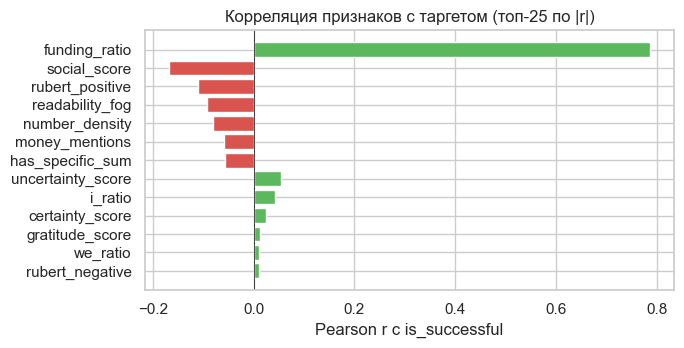

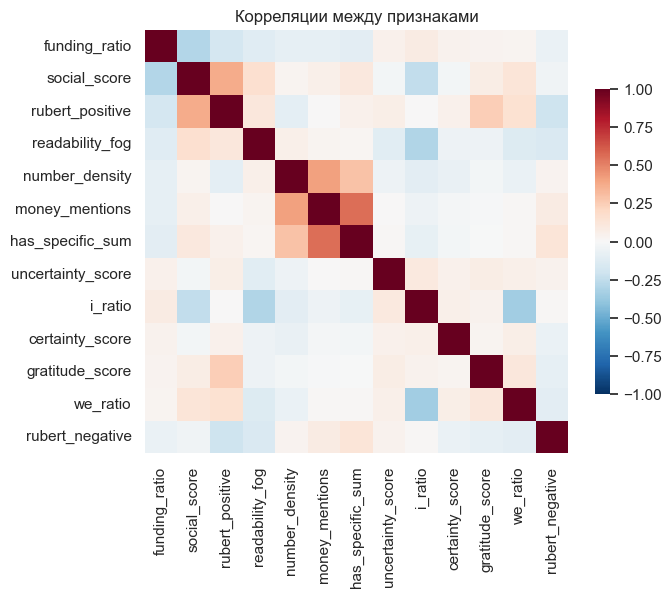

In [29]:
# ── Корреляции признаков с таргетом и между собой ─────────────────────────────
# Логика: до моделей — понять, какие фичи вообще линейно связаны с is_successful,
#         и где скрыта мультиколлинеарность (важно для Logit/Probit с HC1).
# Берём те же фичи, что попадут в модели (log-трансформированные счётчики).
from scipy import stats as _stats

# 1. Собираем все численные/бинарные признаки, которые реально попадут в модели.
FEATURE_CANDIDATES = [
    # целевая
    "funding_ratio",
    # контроли (log-трансформированные)
    "log_goal", "log_duration_days",
    "log_newsCount", "log_commentsCount",
    "log_campaignsAmount",
    "has_video", "log_text_length",
    "log_image_count", "log_reward_count",
    # LIWC-лексика
    "social_score", "gratitude_score",
    "we_ratio", "i_ratio",
    "certainty_score", "uncertainty_score",
    "money_mentions", "number_density", "has_specific_sum",
    "readability_fog",
    # RuBERT + LDA
    "rubert_positive", "rubert_negative",
] + [c for c in df.columns if c.startswith("topic_")]

corr_cols_available = [c for c in FEATURE_CANDIDATES if c in df.columns]
print(f"признаков для корреляций: {len(corr_cols_available)}")

X_corr = (
    df[corr_cols_available + [TARGET_COL]]
    .apply(pd.to_numeric, errors="coerce")
    .dropna(subset=[TARGET_COL])
)
y_corr = X_corr[TARGET_COL].astype(float)

# 2. Корреляции признаков с таргетом + p-значения
rows = []
for col in corr_cols_available:
    s = X_corr[col].fillna(0).astype(float)
    if s.nunique() <= 1:
        continue
    r, p = _stats.pearsonr(s, y_corr)
    rows.append({"feature": col, "r_target": r, "abs_r": abs(r), "p_value": p})

corr_target = (
    pd.DataFrame(rows)
    .sort_values("abs_r", ascending=False)
    .reset_index(drop=True)
)
print("\n── Топ-20 признаков по |corr| с is_successful ──")
print(corr_target.head(20).round(4).to_string(index=False))

# 3. Визуализация: bar-plot корреляций с таргетом
fig, ax = plt.subplots(figsize=(7, max(3, 0.28 * len(corr_target))))
top = corr_target.head(25).iloc[::-1]
colors = ["#5cb85c" if r > 0 else "#d9534f" for r in top["r_target"]]
ax.barh(top["feature"], top["r_target"], color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Pearson r c is_successful")
ax.set_title("Корреляция признаков с таргетом (топ-25 по |r|)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/corr_features_vs_target.png", dpi=120, bbox_inches="tight")
plt.show()

# 4. Матрица корреляций между признаками — смотрим мультиколлинеарность
feat_for_matrix = corr_target["feature"].tolist()
corr_mat = X_corr[feat_for_matrix].fillna(0).astype(float).corr()

fig, ax = plt.subplots(figsize=(max(7, 0.4 * len(feat_for_matrix)),
                                max(6, 0.4 * len(feat_for_matrix))))
sns.heatmap(
    corr_mat, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, cbar_kws={"shrink": 0.7},
    xticklabels=True, yticklabels=True,
)
plt.title("Корреляции между признаками")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/corr_features_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

## 13. Наборы признаков

- **A (контроли)** — непричастные к тексту контролы: цель, длительность, активность автора, наличие видео, длина текста, количество картинок/ссылок.
- **B (текст)** — только текстовые признаки.
- **C (контроли + текст + категории)** — всё сразу.
- **D (только RuBERT + LDA)** — «чёрный ящик» без ручных словарей.


In [28]:
CONTROLS = [
    "log_goal", "log_duration_days",
    "log_newsCount", "log_commentsCount",
    "log_campaignsAmount",
    "has_video", "log_text_length",
    #"log_image_count", # мб убрать
    "log_reward_count",
    "card.author.campaignsAmount"
]

TEXT_LEXICAL = [
    "social_score", "gratitude_score",
    "i_ratio",
    "certainty_score", "uncertainty_score",
    "money_mentions", "number_density", "has_specific_sum",
    "readability_fog",
]
TEXT_BLACKBOX = [
    "rubert_positive", "rubert_negative",
] + [f"topic_{i}" for i in range(LDA_NUM_TOPICS - 1)]

TEXT_ALL = TEXT_LEXICAL + TEXT_BLACKBOX


def _avail(cols):
    return [c for c in cols if c in df.columns]


FEATURE_SETS = {
    "A_controls":        _avail(CONTROLS + CATEGORY_DUMMIES), #+ YEAR_DUMMIES
    "B_text_only":       _avail(TEXT_ALL),
    "C_all":             _avail(CONTROLS + CATEGORY_DUMMIES + TEXT_ALL), #+ YEAR_DUMMIES
    "D_blackbox_only":   _avail(TEXT_BLACKBOX),
    "E_lexical_only":    _avail(TEXT_LEXICAL),
}
for name, feats in FEATURE_SETS.items():
    print(f"{name:20s} → {len(feats)} признаков")

A_controls           → 1 признаков
B_text_only          → 11 признаков
C_all                → 12 признаков
D_blackbox_only      → 2 признаков
E_lexical_only       → 9 признаков


## 14. Визуализации

1. Распределение таргета.
2. Бокс-плоты: ключевые текстовые признаки в разрезе `is_successful`.
3. Корреляционная матрица текстовых признаков + готовых числовых.
4. Корреляции с таргетом (Point-biserial через Pearson).


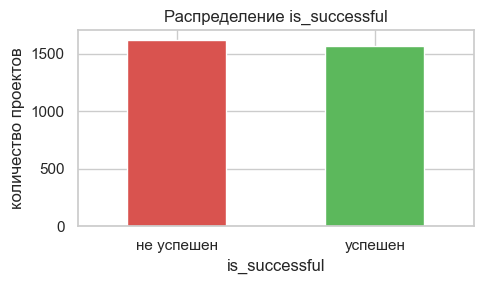

In [19]:
# 14.1 Распределение таргета
fig, ax = plt.subplots(figsize=(5, 3))
df[TARGET_COL].value_counts().sort_index().plot.bar(ax=ax, color=["#d9534f", "#5cb85c"])
ax.set_xticklabels(["не успешен", "успешен"], rotation=0)
ax.set_title("Распределение is_successful")
ax.set_ylabel("количество проектов")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/target_distribution.png", dpi=120)
plt.show()


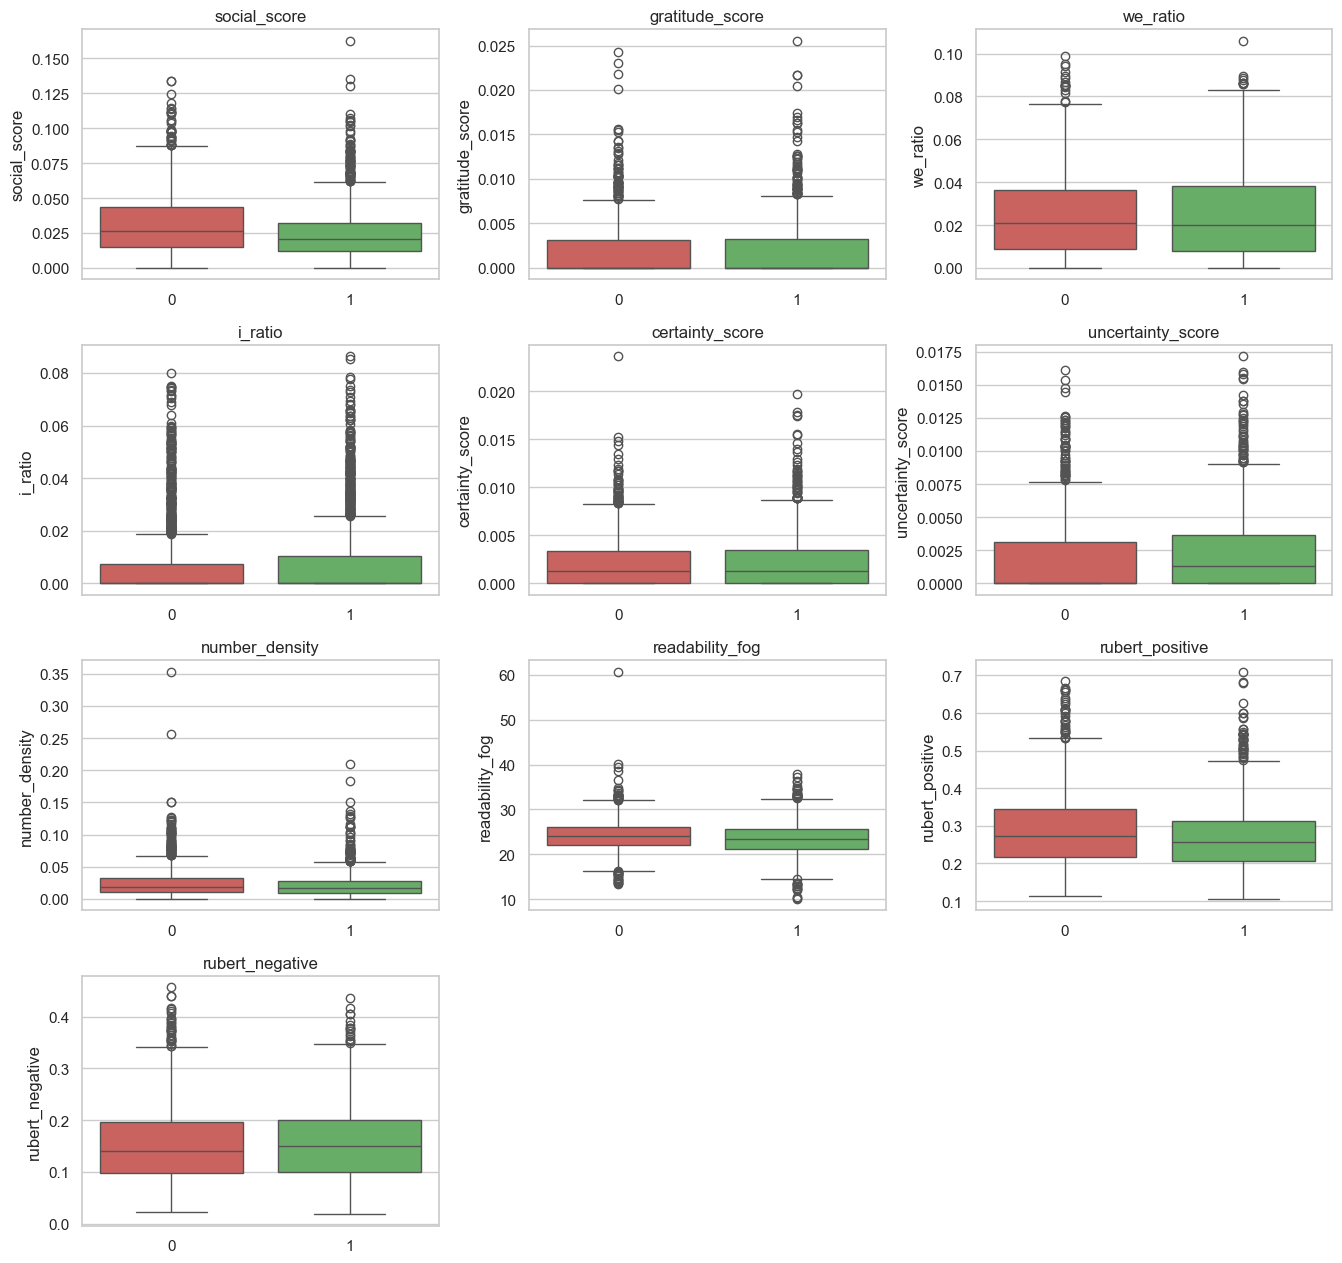

In [20]:
# 14.2 Бокс-плоты: ключевые текстовые признаки vs таргет
key_feats = ["social_score", "gratitude_score", "we_ratio", "i_ratio",
             "certainty_score", "uncertainty_score",
             "number_density", "readability_fog",
             "rubert_positive", "rubert_negative"]
key_feats = [c for c in key_feats if c in df.columns]

ncol = 3
nrow = int(np.ceil(len(key_feats) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 3.2 * nrow))
for ax, f in zip(axes.flat, key_feats):
    sns.boxplot(data=df, x=TARGET_COL, y=f, ax=ax, palette=["#d9534f", "#5cb85c"])
    ax.set_title(f)
    ax.set_xlabel("")
for ax in axes.flat[len(key_feats):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/target_vs_features.png", dpi=120)
plt.show()

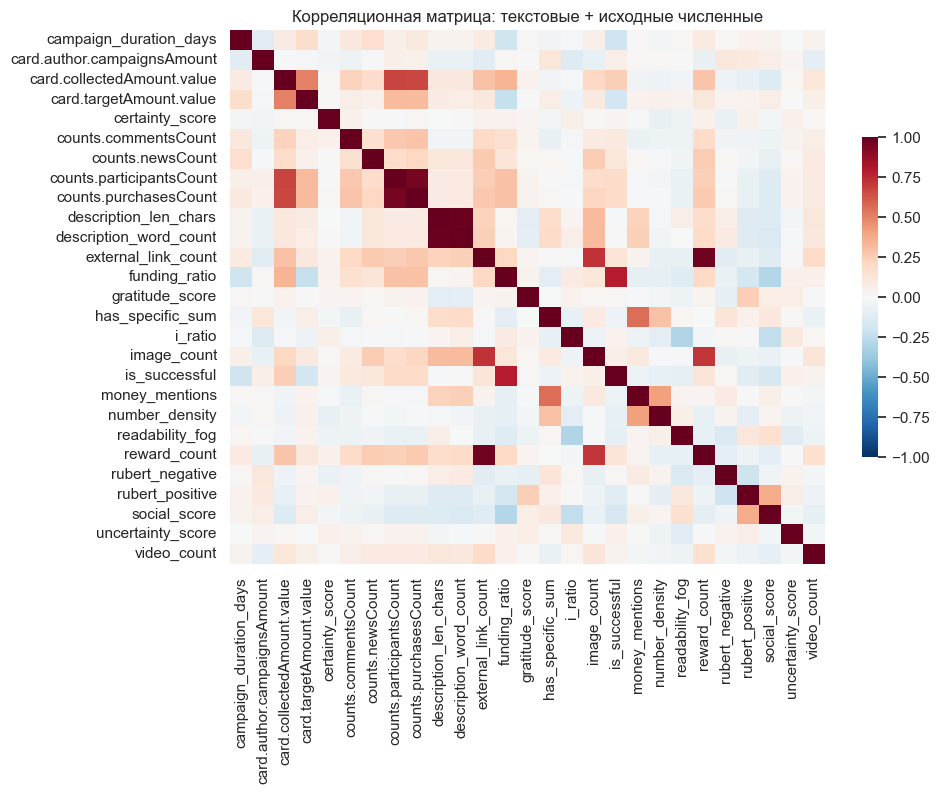

In [30]:
# 14.3 Корреляционная матрица текстовых + базовых численных признаков
numeric_base = ["funding_ratio", "card.targetAmount.value", "card.collectedAmount.value",
                "campaign_duration_days", "counts.newsCount", "counts.commentsCount",
                "counts.participantsCount", "counts.purchasesCount",
                "image_count", "video_count", "reward_count", "external_link_count",
                "description_len_chars", "description_word_count"]
numeric_base = [c for c in numeric_base if c in df.columns]

corr_cols = sorted(set(FEATURE_SETS["C_all"] + numeric_base + [TARGET_COL]))
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].apply(pd.to_numeric, errors="coerce").corr()

plt.figure(figsize=(max(10, 0.35 * len(corr_cols)), max(8, 0.3 * len(corr_cols))))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=False, cbar_kws={"shrink": 0.6})
plt.title("Корреляционная матрица: текстовые + исходные численные")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/corr_matrix.png", dpi=120)
plt.show()


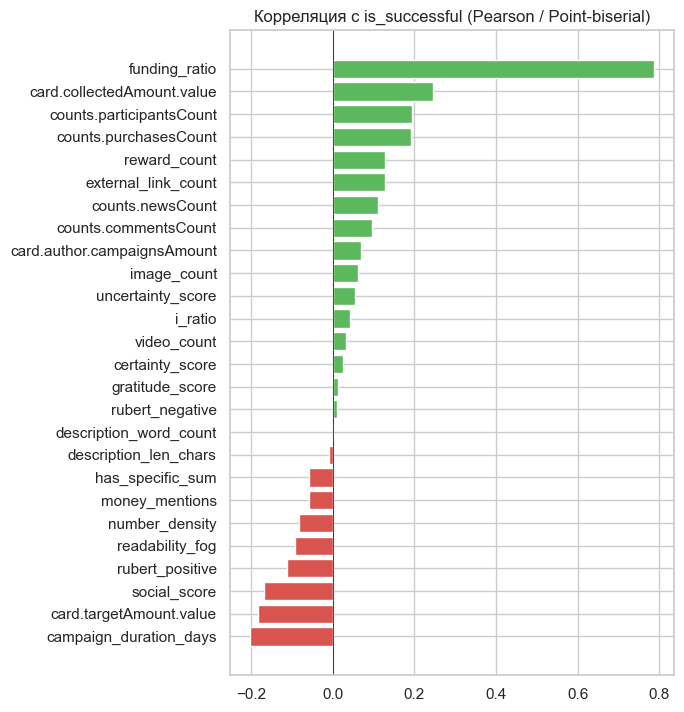

,corr_with_target
campaign_duration_days,-0.202
card.targetAmount.value,-0.184
social_score,-0.168
rubert_positive,-0.111
readability_fog,-0.092
number_density,-0.081
money_mentions,-0.058
has_specific_sum,-0.057
description_len_chars,-0.009
description_word_count,0.000


In [31]:
# 14.4 Корреляции с таргетом, ранжирование
corr_t = (
    df[corr_cols]
    .apply(pd.to_numeric, errors="coerce")
    .corrwith(df[TARGET_COL].astype(float))
    .drop(TARGET_COL, errors="ignore")
    .sort_values()
)
plt.figure(figsize=(7, max(5, 0.28 * len(corr_t))))
colors = ["#d9534f" if v < 0 else "#5cb85c" for v in corr_t]
plt.barh(corr_t.index, corr_t.values, color=colors)
plt.axvline(0, color="black", lw=0.5)
plt.title(f"Корреляция с {TARGET_COL} (Pearson / Point-biserial)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/corr_with_target.png", dpi=120)
plt.show()

corr_t.round(3).to_frame("corr_with_target")


In [33]:
# Проверка масштабов признаков перед фиттингом
feats = FEATURE_SETS["A_controls"]
print(df_fit[feats].describe().loc[["mean", "std", "max"]].T.sort_values("max", ascending=False).head(10))

                                 mean      std   max
card.author.campaignsAmount  4.569549  7.95645  77.0


Нелинейности

- уверенность
- длина текста
- тональность (позитив)

Интеракшен для категории и видео/фото

## 15. Метрические регрессии (Logit)

Таргет бинарный → используем Logit с HC1-ошибками (устойчив к гетероскедастичности) по трём спецификациям: контроли, текст, всё вместе.


In [32]:
df_fit = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)

── VIF: CONTROLS + TEXT (без категориальных и годовых дамми) ──
                    feature      VIF
             money_mentions 1.629834
           has_specific_sum 1.525746
            rubert_positive 1.345589
               social_score 1.265849
             number_density 1.243221
                    i_ratio 1.198666
            readability_fog 1.161583
            rubert_negative 1.113735
            gratitude_score 1.078877
card.author.campaignsAmount 1.065155
          uncertainty_score 1.033174
            certainty_score 1.019505

✓  нет признаков с VIF > 10 — мультиколлинеарность в норме


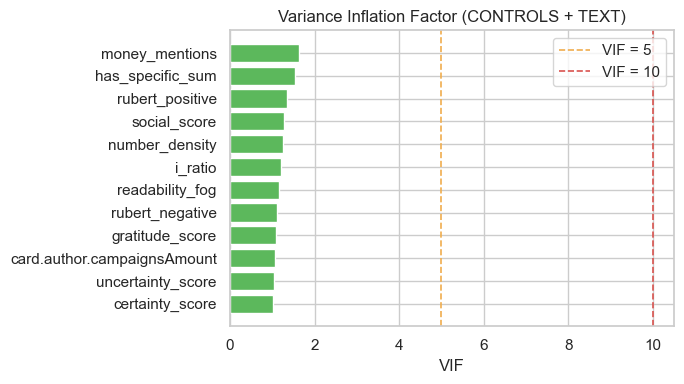

In [35]:
# ═══ VIF: диагностика мультиколлинеарности ═══════════════════════════════════
# Категориальные и годовые дамми намеренно исключены: при большом числе
# категорий их VIF механически завышен — это не информативно.
# Смотрим прежде всего на CONTROLS + TEXT-признаки.
# VIF > 5 — умеренная, VIF > 10 — высокая мультиколлинеарность.

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


def compute_vif(df_src: pd.DataFrame, features: list) -> pd.DataFrame:
    feats = [f for f in features if f in df_src.columns]

    X = (
        df_src[feats]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .astype(float)
    )

    # Убираем константные признаки
    X = X.loc[:, X.nunique() > 1]

    Xc = sm.add_constant(X, has_constant="add")

    vif_vals = [
        variance_inflation_factor(Xc.values, i)
        for i in range(Xc.shape[1])
    ]

    return (
        pd.DataFrame({"feature": Xc.columns, "VIF": vif_vals})
        .query("feature != 'const'")
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )


# Непрерывные и бинарные признаки без дамми категорий и годов
continuous_feats = CONTROLS + TEXT_LEXICAL + TEXT_BLACKBOX
vif_df = compute_vif(df_fit, continuous_feats)

print("── VIF: CONTROLS + TEXT (без категориальных и годовых дамми) ──")
print(vif_df.to_string(index=False))

high_vif = vif_df[vif_df["VIF"] > 10]

if not high_vif.empty:
    print(f"\nVIF > 10: {high_vif['feature'].tolist()}")
else:
    print("\n✓  нет признаков с VIF > 10 — мультиколлинеарность в норме")


# Визуализация
fig, ax = plt.subplots(figsize=(7, max(4, 0.32 * len(vif_df))))

colors = [
    "#d9534f" if v > 10 else "#f0ad4e" if v > 5 else "#5cb85c"
    for v in vif_df["VIF"]
]

ax.barh(
    vif_df["feature"].iloc[::-1],
    vif_df["VIF"].iloc[::-1],
    color=list(reversed(colors))
)

ax.axvline(5, color="#f0ad4e", lw=1.2, ls="--", label="VIF = 5")
ax.axvline(10, color="#d9534f", lw=1.2, ls="--", label="VIF = 10")

ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor (CONTROLS + TEXT)")
ax.legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/vif_plot.png", dpi=120, bbox_inches="tight")
plt.show()


In [38]:
import statsmodels.api as sm

# CATEGORY_DUMMIES и YEAR_DUMMIES уже исключают базовую категорию/год
# (см. cell 31). Дополнительная фильтрация BASE_CAT/BASE_YEAR не нужна —
# константные колонки (например, year-дамми с нулевой частотой) отсеиваются
# через X.nunique() > 1.

# ── bool → int для всех булевых колонок ───────────────────────────────────
bool_cols = df_fit.select_dtypes(include="bool").columns.tolist()
df_fit[bool_cols] = df_fit[bool_cols].astype(int)
print(f"Сконвертировано bool→int: {len(bool_cols)} колонок")

y = df_fit[TARGET_COL].astype(int)

logit_results = {}

for name, feats in FEATURE_SETS.items():
    feats = [f for f in feats if f in df_fit.columns]

    print(f"\n{'─'*60}")
    print(f"[{name}] признаки ({len(feats)} шт.): {feats}")
    print(f"{'─'*60}")

    X = (
        df_fit[feats]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .astype(float)
    )
    # Отсеиваем константные колонки (year-дамми с нулевой частотой и т.п.)
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")

    model = sm.Logit(y, X).fit(disp=0, maxiter=200)

    print(model.summary())
    logit_results[name] = model

Сконвертировано bool→int: 0 колонок

────────────────────────────────────────────────────────────
[A_controls] признаки (1 шт.): ['card.author.campaignsAmount']
────────────────────────────────────────────────────────────
                           Logit Regression Results                           
Dep. Variable:          is_successful   No. Observations:                 3192
Model:                          Logit   Df Residuals:                     3190
Method:                           MLE   Df Model:                            1
Date:                Sat, 02 May 2026   Pseudo R-squ.:                0.003652
Time:                        19:54:03   Log-Likelihood:                -2204.0
converged:                       True   LL-Null:                       -2212.1
Covariance Type:            nonrobust   LLR p-value:                 5.829e-05
                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

## 15b. Probit-регрессия

Альтернатива логиту: та же бинарная целевая `is_successful`, но ошибки задаются через нормальное CDF. Коэффициенты уже не интерпретируются как `log-odds`; сравниваем с логитом через AIC / pseudo R² и знак коэффициентов (должны совпадать).


In [39]:
import statsmodels.api as sm

probit_results = {}

for name, feats in FEATURE_SETS.items():
    feats = [f for f in feats if f in df_fit.columns]

    print(f"\n{'─'*60}")
    print(f"[{name}] признаки ({len(feats)} шт.): {feats}")
    print(f"{'─'*60}")

    X = (
        df_fit[feats]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .astype(float)
    )
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")

    model = sm.Probit(y, X).fit(disp=0, maxiter=200)

    print(model.summary())
    probit_results[name] = model


# ── Сравнение Logit vs Probit на каждом наборе признаков ─────────────────
print("\n── Logit vs Probit ──")
rows = []
for name in FEATURE_SETS:
    if name in logit_results and name in probit_results:
        L = logit_results[name]
        P = probit_results[name]
        rows.append({
            "набор":          name,
            "logit_R2":       round(L.prsquared, 3),
            "probit_R2":      round(P.prsquared, 3),
            "logit_AIC":      round(L.aic, 1),
            "probit_AIC":     round(P.aic, 1),
        })

print(pd.DataFrame(rows).to_string(index=False))


────────────────────────────────────────────────────────────
[A_controls] признаки (1 шт.): ['card.author.campaignsAmount']
────────────────────────────────────────────────────────────
                          Probit Regression Results                           
Dep. Variable:          is_successful   No. Observations:                 3192
Model:                         Probit   Df Residuals:                     3190
Method:                           MLE   Df Model:                            1
Date:                Sat, 02 May 2026   Pseudo R-squ.:                0.003616
Time:                        19:54:06   Log-Likelihood:                -2204.1
converged:                       True   LL-Null:                       -2212.1
Covariance Type:            nonrobust   LLR p-value:                 6.340e-05
                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------

## 16. ML-модели

Одна и та же бинарная цель `is_successful`, пять моделей, четыре набора признаков. Валидация: Stratified K-Fold (или LOOCV при малом классе).


In [40]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, average_precision_score)
from tqdm.auto import tqdm
import numpy as np
import pandas as pd


# ─────────────────────────────────────────────────────────────────────────────
# 1. Фабрика моделей
# ─────────────────────────────────────────────────────────────────────────────

def make_models():
    models = {
        "LogReg_L1": Pipeline([
            ("sc",  StandardScaler()),
            ("clf", LogisticRegression(
                penalty="l1", solver="saga",
                max_iter=5000, class_weight="balanced",
                random_state=RANDOM_STATE)),
        ]),
        "RandomForest": RandomForestClassifier(
            n_estimators=300, random_state=RANDOM_STATE,
            class_weight="balanced", n_jobs=-1),
        "GradBoost": GradientBoostingClassifier(
            n_estimators=200, max_depth=3,
            random_state=RANDOM_STATE),
    }

    try:
        from lightgbm import LGBMClassifier
        models["LightGBM"] = LGBMClassifier(
            n_estimators=200, random_state=RANDOM_STATE,
            class_weight="balanced", verbose=-1, n_jobs=-1)
    except ImportError:
        print("LightGBM не установлен — пропускаем.")

    try:
        from xgboost import XGBClassifier
        models["XGBoost"] = XGBClassifier(
            n_estimators=200, max_depth=4,
            use_label_encoder=False,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1)
    except ImportError:
        print("XGBoost не установлен — пропускаем.")

    return models


# ─────────────────────────────────────────────────────────────────────────────
# 2. Выбор сплиттера
# ─────────────────────────────────────────────────────────────────────────────

def cv_splitter(y):
    min_class = y.value_counts().min()
    if len(y) < 30 or min_class < 5:
        return LeaveOneOut(), "LOOCV"
    n_splits = min(CV_FOLDS, min_class)
    return (StratifiedKFold(n_splits=n_splits, shuffle=True,
                            random_state=RANDOM_STATE),
            f"Stratified {n_splits}-Fold")


# ─────────────────────────────────────────────────────────────────────────────
# 3. Оценка одной модели
# ─────────────────────────────────────────────────────────────────────────────

def eval_model(model, X, y, splitter):
    """
    Возвращает словарь метрик или {'error': ...} при сбое.
    """
    try:
        proba = cross_val_predict(
            model, X, y, cv=splitter, method="predict_proba"
        )[:, 1]
    except Exception as e:
        return {"ROC_AUC": np.nan, "PR_AUC": np.nan,
                "F1": np.nan, "Precision": np.nan,
                "Recall": np.nan, "error": str(e)}

    pred = (proba >= TEST_THRESHOLD).astype(int)

    return {
        "ROC_AUC":   roc_auc_score(y, proba)            if y.nunique() > 1 else np.nan,
        "PR_AUC":    average_precision_score(y, proba)  if y.nunique() > 1 else np.nan,
        "F1":        f1_score(y, pred, zero_division=0),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall":    recall_score(y, pred, zero_division=0),
        "error":     None,
    }


# ─────────────────────────────────────────────────────────────────────────────
# 4. Основной цикл
# ─────────────────────────────────────────────────────────────────────────────

splitter, split_name = cv_splitter(y)
print(f"CV: {split_name}  "
      f"(n={len(y)}, min_class={y.value_counts().min()})\n")

# Считаем общее число итераций для прогресс-бара
valid_sets  = {k: v for k, v in FEATURE_SETS.items() if v}
model_names = list(make_models().keys())
total_iters = len(valid_sets) * len(model_names)

rows = []

with tqdm(total=total_iters, desc="ML grid", unit="run") as pbar:
    for set_name, feats in valid_sets.items():

        # Подготовка матрицы признаков
        X = (df_fit[feats]
             .apply(pd.to_numeric, errors="coerce")
             .fillna(0)
             .astype(float))

        # Пересоздаём модели на каждом наборе признаков,
        # чтобы избежать утечки состояния между итерациями
        for m_name, model in make_models().items():
            pbar.set_postfix({"set": set_name, "model": m_name})

            metrics = eval_model(model, X, y, splitter)

            # Выводим ошибку, если она есть, но не прерываем цикл
            if metrics.get("error"):
                tqdm.write(f"  [!] {set_name} / {m_name}: {metrics['error']}")

            rows.append({
                "set":   set_name,
                "model": m_name,
                **{k: v for k, v in metrics.items() if k != "error"},
            })

            pbar.update(1)

# ─────────────────────────────────────────────────────────────────────────────
# 5. Результаты
# ─────────────────────────────────────────────────────────────────────────────

results_table = (
    pd.DataFrame(rows)
    .sort_values(["set", "ROC_AUC"], ascending=[True, False])
    .reset_index(drop=True)
    .round(4)
)

# Сводная таблица: лучшая модель по каждому набору признаков
best_per_set = (
    results_table
    .dropna(subset=["ROC_AUC"])
    .loc[results_table.groupby("set")["ROC_AUC"].idxmax()]
    .reset_index(drop=True)
)

print("\n=== Полная таблица результатов ===")
print(results_table.to_string(index=False))

print("\n=== Лучшая модель по каждому набору признаков ===")
print(best_per_set.to_string(index=False))


CV: Stratified 5-Fold  (n=3192, min_class=1570)



ML grid: 100%|██████████| 25/25 [01:07<00:00,  2.69s/run, set=E_lexical_only, model=XGBoost]      


=== Полная таблица результатов ===
            set        model  ROC_AUC  PR_AUC     F1  Precision  Recall
     A_controls    LogReg_L1   0.5467  0.5327 0.3772     0.5493  0.2873
     A_controls      XGBoost   0.5375  0.5307 0.4478     0.5458  0.3796
     A_controls    GradBoost   0.5373  0.5298 0.4455     0.5468  0.3758
     A_controls     LightGBM   0.5372  0.5267 0.4515     0.5450  0.3854
     A_controls RandomForest   0.5371  0.5307 0.4489     0.5450  0.3815
    B_text_only    LogReg_L1   0.6122  0.5799 0.6105     0.5699  0.6573
    B_text_only RandomForest   0.6097  0.5902 0.5838     0.5661  0.6025
    B_text_only    GradBoost   0.5924  0.5662 0.5660     0.5513  0.5815
    B_text_only     LightGBM   0.5894  0.5691 0.5621     0.5549  0.5694
    B_text_only      XGBoost   0.5750  0.5552 0.5500     0.5435  0.5567
          C_all RandomForest   0.6334  0.6133 0.5929     0.5819  0.6045
          C_all    LogReg_L1   0.6286  0.5991 0.6167     0.5808  0.6573
          C_all     LightGBM

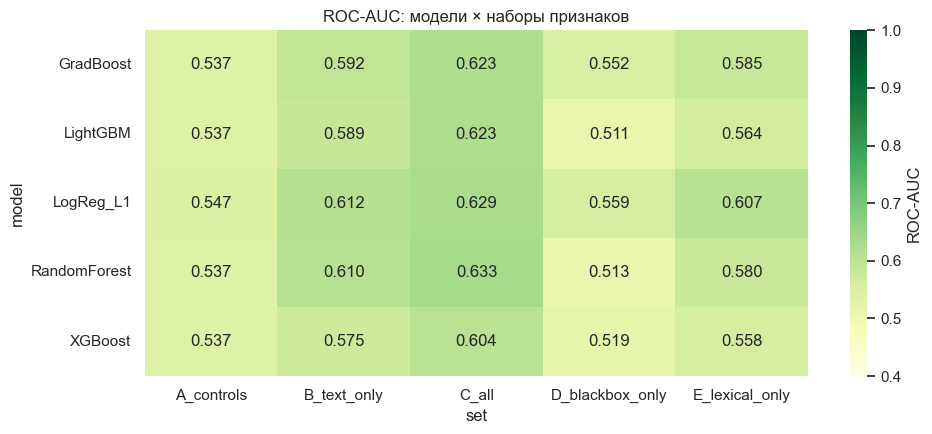

In [41]:
# Визуализация сравнения моделей
if "ROC_AUC" in results_table.columns:
    pivot = results_table.pivot(index="model", columns="set", values="ROC_AUC")
    plt.figure(figsize=(10, 4.5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGn", vmin=0.4, vmax=1.0,
                cbar_kws={"label": "ROC-AUC"})
    plt.title("ROC-AUC: модели × наборы признаков")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/ml_comparison.png", dpi=120)
    plt.show()


## 17. SHAP

Берём лучшую tree-модель на полном наборе признаков C и строим beeswarm + bar через `shap.TreeExplainer`.


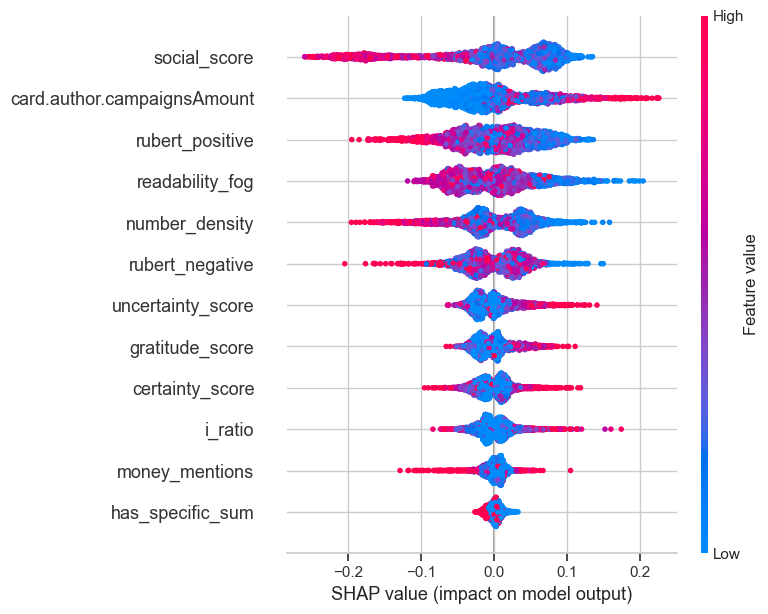

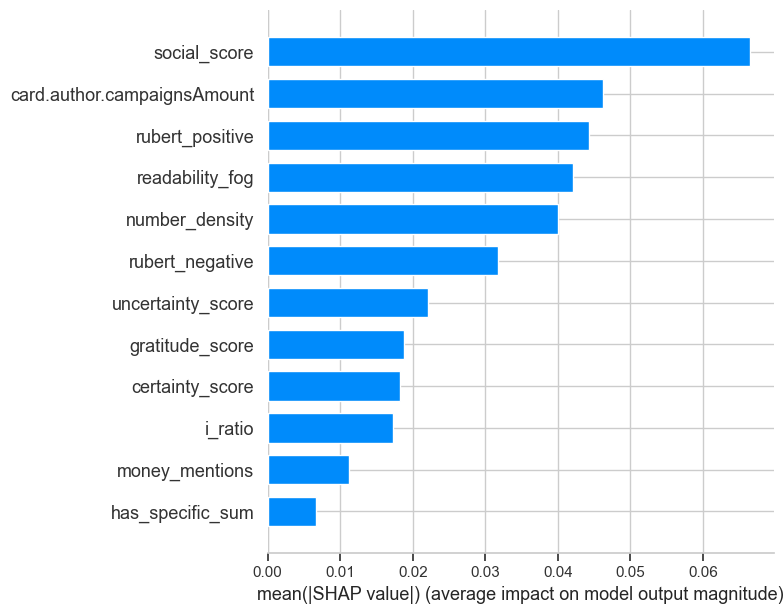

,mean_|SHAP|
social_score,0.0665
card.author.campaignsAmount,0.0463
rubert_positive,0.0443
readability_fog,0.0420
number_density,0.0400
rubert_negative,0.0317
uncertainty_score,0.0222
gratitude_score,0.0188
certainty_score,0.0182
i_ratio,0.0172


In [42]:
# ═══ КОЛОНКИ МОДЕЛИ — SHAP на RandomForest ════════════════════════════════════
# Логика: объясняем «лучшую» tree-модель на полном наборе C_all
# (контроли + категории + годы + весь текст). Берём C_all, потому что хотим
# увидеть, какие именно признаки выбились в топ-важности среди всех доступных.
# ═════════════════════════════════════════════════════════════════════════════

import shap

best_feats = FEATURE_SETS["C_all"]
X_shap = df_fit[best_feats].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)

rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE,
                            class_weight="balanced")
rf.fit(X_shap, y)

explainer = shap.TreeExplainer(rf)
sv = explainer.shap_values(X_shap)

if isinstance(sv, list):
    sv = sv[1]
sv = np.asarray(sv)
if sv.ndim == 3:
    sv = sv[:, :, 1]

# beeswarm
plt.figure()
shap.summary_plot(sv, X_shap, show=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

# bar
plt.figure()
shap.summary_plot(sv, X_shap, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/shap_bar.png", dpi=120, bbox_inches="tight")
plt.show()

mean_abs = (pd.Series(np.abs(sv).mean(axis=0), index=X_shap.columns)
              .sort_values(ascending=False))
mean_abs.round(4).to_frame("mean_|SHAP|")


## 19. Категориальный таргет: `funding_bucket`

Дробим `funding_ratio` на три класса:

- `0` — провал (<0.5 от цели)
- `1` — частичный успех (0.5 — 1.0)
- `2` — полный сбор / оверфандинг (≥1.0)

Эти классы естественно упорядочены, поэтому прогоняем две модели:
1. **Multinomial logit** (`sm.MNLogit`) — не использует порядок.
2. **Ordered logit / ordered probit** (`OrderedModel`) — явно учитывает порядок.


funding_bucket распределение:
  0 · <0.5 (провал)         : 550 (17.2%)
  1 · 0.5–1 (частичный)     : 1072 (33.6%)
  2 · >=1 (успех)           : 1570 (49.2%)


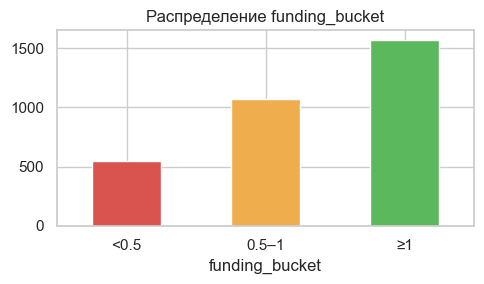

In [36]:
from statsmodels.miscmodels.ordinal_model import OrderedModel


def make_funding_bucket(series: pd.Series) -> pd.Series:
    bins = [-np.inf, 0.5, 1.0, np.inf]
    labels = [0, 1, 2]  # 0: <0.5, 1: 0.5-1, 2: >=1
    return pd.cut(series, bins=bins, labels=labels, right=False).astype(int)


df_fit["funding_bucket"] = make_funding_bucket(df_fit["funding_ratio"].fillna(0))

bucket_counts = df_fit["funding_bucket"].value_counts().sort_index()
print("funding_bucket распределение:")
for k, v in bucket_counts.items():
    name = {0: "<0.5 (провал)", 1: "0.5–1 (частичный)", 2: ">=1 (успех)"}[k]
    print(f"  {k} · {name:22s}: {v:3d} ({v/len(df_fit)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 3))
bucket_counts.plot.bar(ax=ax, color=["#d9534f", "#f0ad4e", "#5cb85c"])
ax.set_xticklabels(["<0.5", "0.5–1", "≥1"], rotation=0)
ax.set_title("Распределение funding_bucket")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/funding_bucket_distribution.png", dpi=120)
plt.show()


### 19.1 Multinomial Logit

Модель выбирает между тремя классами независимо. Базовая категория — `0` (провал). Коэффициенты интерпретируются как `log-odds` класса vs базовой.


In [37]:
# ═══ КОЛОНКИ МОДЕЛИ — Multinomial Logit (3 класса funding_bucket) ════════════
# Логика: цель — 3 класса (провал/частичный/успех). Смотрим две спецификации:
#   A_controls — baseline на контролях + категориях + годах;
#   C_all      — + весь текст: смотрим, добавляет ли текст к «контролю успеха».
# Колонки: те же FEATURE_SETS, что в логите/пробите.
# BFGS вместо Newton: более устойчив к плохой обусловленности гессиана.
# ═════════════════════════════════════════════════════════════════════════════

def fit_mnlogit(X: pd.DataFrame, y: pd.Series, label: str):
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")
    if X.shape[1] >= len(y):
        print(f"[{label}] пропуск: предикторов ({X.shape[1]}) ≥ наблюдений ({len(y)})")
        return None
    try:
        model = sm.MNLogit(y, X).fit(method="bfgs", disp=0, maxiter=500)
    except Exception as e:
        print(f"[{label}] ошибка: {e}")
        return None
    print(f"\n══ MNLogit · {label} ══")
    print(f"  n={int(model.nobs)}  pseudo R²={model.prsquared:.3f}  "
          f"LLR p={model.llr_pvalue:.4g}  AIC={model.aic:.1f}")
    print(model.summary().as_text()[:3000])
    return model


y_bucket = df_fit["funding_bucket"].astype(int)
mnlogit_model = None
for name in ("A_controls", "C_all"):
    feats = [f for f in FEATURE_SETS[name] if f in df_fit.columns]
    m = fit_mnlogit(df_fit[feats], y_bucket, name)
    if m is not None and name == "C_all":
        mnlogit_model = m


══ MNLogit · A_controls ══
  n=3192  pseudo R²=0.343  LLR p=0  AIC=4342.9
                          MNLogit Regression Results                          
Dep. Variable:         funding_bucket   No. Observations:                 3192
Model:                        MNLogit   Df Residuals:                     3156
Method:                           MLE   Df Model:                           34
Date:                Sat, 02 May 2026   Pseudo R-squ.:                  0.3431
Time:                        14:47:50   Log-Likelihood:                -2135.4
converged:                       True   LL-Null:                       -3250.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    funding_bucket=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                    3.6778      1.663      2.211      0.027   

### 19.2 Ordered Logit / Ordered Probit

Обе модели используют порядок классов (0 < 1 < 2). Отличаются только распределением латентной переменной: logit → логистическое, probit → нормальное. Сравниваем по AIC / log-likelihood.


In [38]:
# ═══ КОЛОНКИ МОДЕЛИ — Ordered Logit / Ordered Probit ═════════════════════════
# Логика: 3 класса funding_bucket УПОРЯДОЧЕНЫ (0 < 1 < 2). Ordered модель
# использует этот порядок → меньше параметров, чем MNLogit. Набор C_all —
# чтобы ответить «что сдвигает проект вверх по шкале успешности».
# Колонки: FEATURE_SETS["C_all"] = контроли + категории + годы + текст.
# ═════════════════════════════════════════════════════════════════════════════

def fit_ordered(X: pd.DataFrame, y: pd.Series, distr: str, label: str):
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    if X.shape[1] >= len(y) - 3:
        print(f"[{label}/{distr}] пропуск: слишком мало наблюдений")
        return None
    try:
        model = OrderedModel(y, X, distr=distr).fit(method="bfgs", disp=0, maxiter=300)
    except Exception as e:
        print(f"[{label}/{distr}] ошибка: {e}")
        return None
    print(f"\n══ Ordered {distr} · {label} ══  n={int(model.nobs)}  "
          f"AIC={model.aic:.1f}  LLF={model.llf:.2f}")
    summ = pd.DataFrame({
        "coef": model.params, "se": model.bse,
        "z":    model.tvalues, "p":  model.pvalues,
    }).round(4)
    print(summ.sort_values("p").to_string())
    return model


ordered_results = {}
for distr in ("logit", "probit"):
    feats = [f for f in FEATURE_SETS["C_all"] if f in df_fit.columns]
    m = fit_ordered(df_fit[feats], y_bucket, distr=distr, label="C_all")
    if m is not None:
        ordered_results[distr] = m

if len(ordered_results) == 2:
    print("\n── Ordered Logit vs Ordered Probit ──")
    print(pd.DataFrame({
        "distr": list(ordered_results),
        "AIC":   [m.aic for m in ordered_results.values()],
        "LLF":   [m.llf for m in ordered_results.values()],
    }).round(3).to_string(index=False))



══ Ordered logit · C_all ══  n=3192  AIC=5165.5  LLF=-2552.75
                                         coef       se        z       p
log_goal                              -0.4692   0.0417 -11.2596  0.0000
social_score                          -9.4448   2.2716  -4.1578  0.0000
cat_Творческие (кино, театр, дизайн)   1.7886   0.1548  11.5573  0.0000
0/1                                   -8.2094   0.8111 -10.1210  0.0000
cat_Образование и просвещение          2.3498   0.2605   9.0197  0.0000
cat_Музыка                             2.2331   0.1585  14.0883  0.0000
cat_Литература                         2.1009   0.1527  13.7560  0.0000
cat_Досуг и события                    1.9821   0.1859  10.6636  0.0000
cat_Бизнес                             2.4370   0.4516   5.3966  0.0000
cat_Социальные                         2.3975   0.1633  14.6854  0.0000
log_reward_count                       0.3889   0.0809   4.8102  0.0000
log_duration_days                     -0.6662   0.0648 -10.2820  0.0000
l

In [39]:
# ═══ КОЛОНКИ МОДЕЛИ — Ordered Logit / Ordered Probit ═════════════════════════
# Логика: 3 класса funding_bucket УПОРЯДОЧЕНЫ (0 < 1 < 2). Ordered модель
# использует этот порядок → меньше параметров, чем MNLogit. Набор C_all —
# чтобы ответить «что сдвигает проект вверх по шкале успешности».
# Колонки: FEATURE_SETS["C_all"] = контроли + категории + годы + текст.
# ═════════════════════════════════════════════════════════════════════════════

def fit_ordered(X: pd.DataFrame, y: pd.Series, distr: str, label: str):
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    if X.shape[1] >= len(y) - 3:
        print(f"[{label}/{distr}] пропуск: слишком мало наблюдений")
        return None
    try:
        model = OrderedModel(y, X, distr=distr).fit(method="bfgs", disp=0, maxiter=300)
    except Exception as e:
        print(f"[{label}/{distr}] ошибка: {e}")
        return None
    print(f"\n══ Ordered {distr} · {label} ══  n={int(model.nobs)}  "
          f"AIC={model.aic:.1f}  LLF={model.llf:.2f}")
    summ = pd.DataFrame({
        "coef": model.params, "se": model.bse,
        "z":    model.tvalues, "p":  model.pvalues,
    }).round(4)
    print(summ.sort_values("p").to_string())
    return model


ordered_results = {}
for distr in ("logit", "probit"):
    feats = [f for f in FEATURE_SETS["C_all"] if f in df_fit.columns]
    m = fit_ordered(df_fit[feats], y_bucket, distr=distr, label="C_all")
    if m is not None:
        ordered_results[distr] = m

if len(ordered_results) == 2:
    print("\n── Ordered Logit vs Ordered Probit ──")
    print(pd.DataFrame({
        "distr": list(ordered_results),
        "AIC":   [m.aic for m in ordered_results.values()],
        "LLF":   [m.llf for m in ordered_results.values()],
    }).round(3).to_string(index=False))



══ Ordered logit · C_all ══  n=3192  AIC=5165.5  LLF=-2552.75
                                         coef       se        z       p
log_goal                              -0.4692   0.0417 -11.2596  0.0000
social_score                          -9.4448   2.2716  -4.1578  0.0000
cat_Творческие (кино, театр, дизайн)   1.7886   0.1548  11.5573  0.0000
0/1                                   -8.2094   0.8111 -10.1210  0.0000
cat_Образование и просвещение          2.3498   0.2605   9.0197  0.0000
cat_Музыка                             2.2331   0.1585  14.0883  0.0000
cat_Литература                         2.1009   0.1527  13.7560  0.0000
cat_Досуг и события                    1.9821   0.1859  10.6636  0.0000
cat_Бизнес                             2.4370   0.4516   5.3966  0.0000
cat_Социальные                         2.3975   0.1633  14.6854  0.0000
log_reward_count                       0.3889   0.0809   4.8102  0.0000
log_duration_days                     -0.6662   0.0648 -10.2820  0.0000
l

## 20. Явный train/test split

ML-модели выше оцениваются **кросс-валидацией** (`cross_val_predict`, Stratified K-Fold) — это тоже split, только многократный. Для последующих моделей (GAM, квантильная регрессия, интеракции) делаем один явный hold-out split 80/20 со стратификацией по бинарному таргету.


In [40]:
from sklearn.model_selection import train_test_split as tts

TRAIN_SIZE = 0.8
_feats_all = [f for f in FEATURE_SETS["C_all"] if f in df_fit.columns]

train_idx, test_idx = tts(
    np.arange(len(df_fit)),
    train_size=TRAIN_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_fit[TARGET_COL],
)
df_train = df_fit.iloc[train_idx].reset_index(drop=True)
df_test  = df_fit.iloc[test_idx].reset_index(drop=True)

y_train  = df_train[TARGET_COL].astype(int)
y_test   = df_test[TARGET_COL].astype(int)

print(f"train: {len(df_train)}  (успешных: {int(y_train.sum())})")
print(f"test : {len(df_test)}   (успешных: {int(y_test.sum())})")


train: 2553  (успешных: 1256)
test : 639   (успешных: 314)


## 21. Сплайны / GAM

Линейная регрессия в логите предполагает монотонную зависимость log-odds от предиктора. GAM (Generalized Additive Model) ослабляет это: каждый признак заменяется на гладкую функцию `f_j(x_j)`, оцененную через penalized splines.

Используем `pygam.LogisticGAM` на нескольких ключевых континуальных признаках — видно, где зависимость нелинейна.


GAM признаки: ['log_goal', 'log_duration_days', 'log_text_length', 'readability_fog', 'social_score', 'number_density', 'rubert_positive', 'rubert_negative']

GAM on test: ROC-AUC=0.698  ACC=0.651


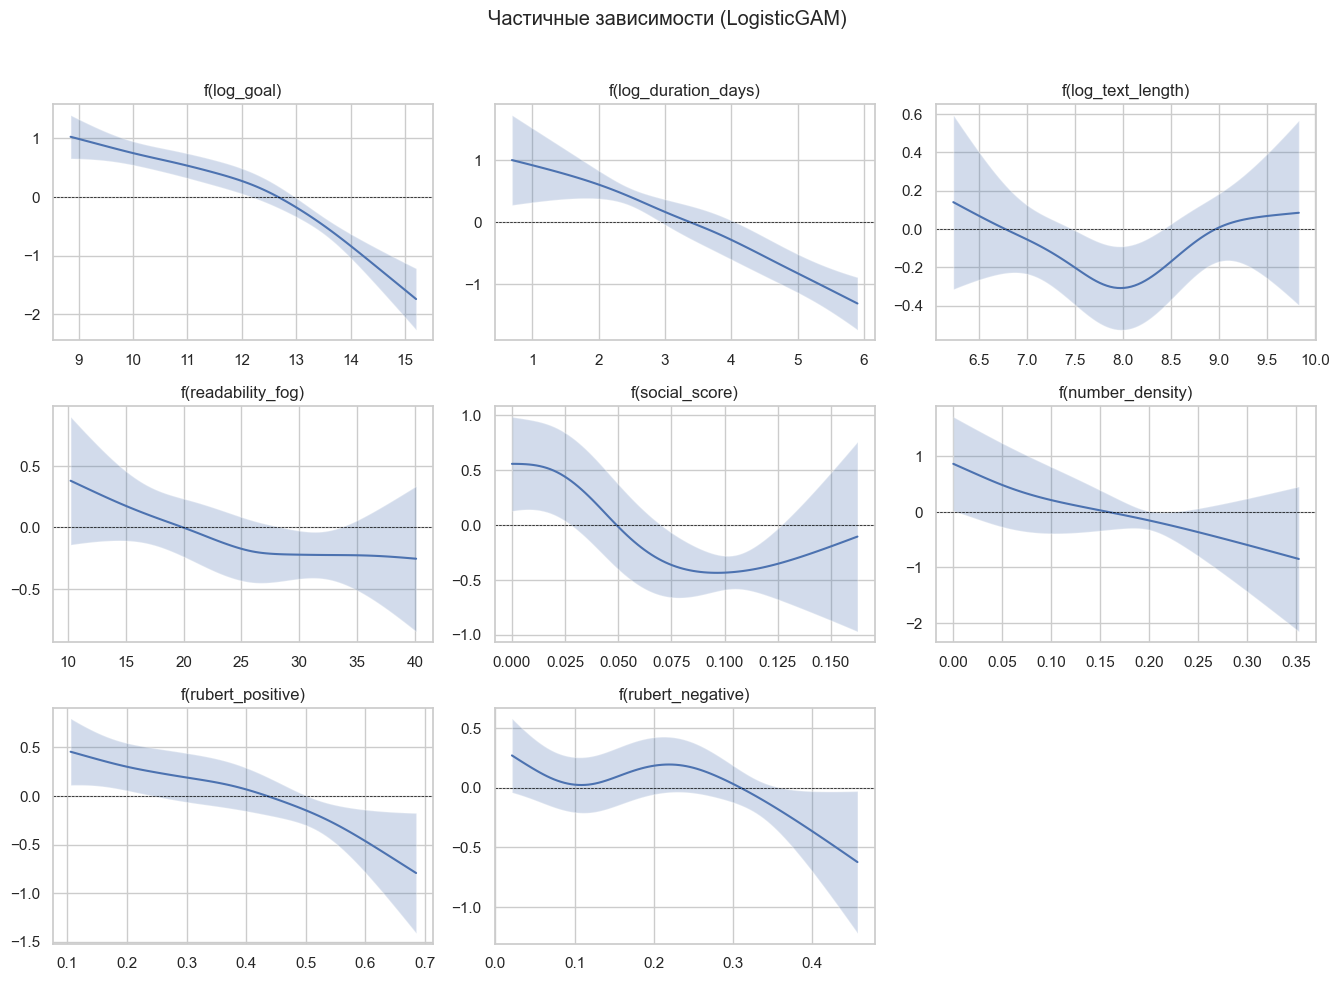

In [41]:
# ═══ КОЛОНКИ МОДЕЛИ — LogisticGAM (сплайны по 8 фичам) ════════════════════════
# Логика: ищем НЕЛИНЕЙНОСТИ там, где они теоретически наиболее вероятны.
# Берём 8 признаков с шансами на не-монотонную связь:
#   log_goal           — слишком малые/большие цели могут вести себя не так, как средние
#   log_duration_days  — оптимум длительности, не «чем дольше, тем лучше»
#   log_text_length    — избыток текста может ухудшать
#   readability_fog    — и слишком простой, и слишком сложный текст плохи
#   social_score       — насыщение (diminishing returns)
#   number_density     — плато после умеренной плотности чисел
#   rubert_positive / rubert_negative — эмоциональные полюса
# Категорий и годов в GAM не добавляем — пакет плохо работает с десятками дамми.
# ═════════════════════════════════════════════════════════════════════════════

try:
    from pygam import LogisticGAM, s, f
    PYGAM_OK = True
except ImportError:
    PYGAM_OK = False
    print("pygam не установлен. Установи: pip install pygam")

GAM_FEATURES = [c for c in [
    "log_goal", "log_duration_days", "log_text_length",
    "readability_fog", "social_score", "number_density",
    "rubert_positive", "rubert_negative",
] if c in df_train.columns]

print(f"GAM признаки: {GAM_FEATURES}")

if PYGAM_OK and GAM_FEATURES:
    X_tr = df_train[GAM_FEATURES].apply(pd.to_numeric, errors="coerce").fillna(0).values
    X_te = df_test[GAM_FEATURES].apply(pd.to_numeric, errors="coerce").fillna(0).values

    terms = s(0)
    for i in range(1, len(GAM_FEATURES)):
        terms = terms + s(i)

    gam = LogisticGAM(terms).gridsearch(X_tr, y_train.values, progress=False)

    from sklearn.metrics import roc_auc_score, accuracy_score
    proba_te = gam.predict_proba(X_te)
    print(f"\nGAM on test: ROC-AUC={roc_auc_score(y_test, proba_te):.3f}  "
          f"ACC={accuracy_score(y_test, (proba_te >= 0.5).astype(int)):.3f}")

    # Частичные зависимости — где проявляется нелинейность
    n = len(GAM_FEATURES)
    ncol = 3
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 3.2 * nrow))
    for i, (ax, fname) in enumerate(zip(axes.flat, GAM_FEATURES)):
        XX = gam.generate_X_grid(term=i)
        pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)
        ax.plot(XX[:, i], pdep)
        ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1], alpha=0.25)
        ax.set_title(f"f({fname})")
        ax.axhline(0, color="black", lw=0.5, ls="--")
    for ax in axes.flat[len(GAM_FEATURES):]:
        ax.axis("off")
    plt.suptitle("Частичные зависимости (LogisticGAM)", y=1.02)
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/gam_partial_dependence.png", dpi=120, bbox_inches="tight")
    plt.show()

### 21.1 Ручные сплайн-признаки внутри Logit

Альтернатива пакету `pygam`: добавляем кубические сплайны через `patsy.bs()` и вкладываем их в обычный `sm.Logit`. Это удобно, если нужна совместимость с существующим инструментарием.


In [42]:
# ═══ КОЛОНКИ МОДЕЛИ — Logit со сплайнами (patsy bs), версия 1 ════════════════
# Логика: встраиваем кубические B-сплайны (df=4) по трём контролям, где
# ожидается нелинейность, а остальное оставляем линейным — чтобы результат
# можно было напрямую сравнить с обычным Logit (см. Logit-ячейку).
# Сплайны строятся по:
#   log_goal, log_duration_days, readability_fog
# Плюс остальные колонки из FEATURE_SETS["C_all"] входят линейно
# (контроли + категории + годы + все текстовые фичи).
# ═════════════════════════════════════════════════════════════════════════════

from patsy import dmatrix
from scipy.linalg import qr as _qr_pivoted

# Сплайн от log_goal с 4 базовыми функциями (knots по квантилям)
spline_cols = ["log_goal", "log_duration_days", "readability_fog"]
spline_cols = [c for c in spline_cols if c in df_train.columns]

X_tr_sp = df_train.copy()
X_te_sp = df_test.copy()

# Убираем const если есть в датасете
X_tr_sp = X_tr_sp.drop(columns=['const'], errors='ignore')
X_te_sp = X_te_sp.drop(columns=['const'], errors='ignore')

# "- 1" подавляет глобальный Intercept patsy — иначе dmatrix добавляет
# лишний константный столбец к 4 базисам сплайна (итого 5, а код ожидал 4).
spline_basis_names = {}
for col in spline_cols:
    formula = f"bs({col}, df=4, degree=3, include_intercept=False) - 1"
    bs_tr = dmatrix(formula, data=X_tr_sp, return_type="dataframe")
    bs_te = dmatrix(formula, data=X_te_sp, return_type="dataframe")
    names = [f"{col}_sp{i}" for i in range(bs_tr.shape[1])]
    bs_tr.columns = names
    bs_te.columns = names
    spline_basis_names[col] = names
    X_tr_sp = pd.concat([X_tr_sp.drop(columns=[col]), bs_tr], axis=1)
    X_te_sp = pd.concat([X_te_sp.drop(columns=[col]), bs_te], axis=1)

spline_feature_cols = []
for c in FEATURE_SETS["C_all"]:
    if c in spline_cols:
        spline_feature_cols.extend(spline_basis_names[c])
    elif c in X_tr_sp.columns:
        spline_feature_cols.append(c)

# Logit со сплайнами
X_tr_num = X_tr_sp[spline_feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
X_te_num = X_te_sp[spline_feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)

# Убираем константные столбцы
X_tr_num = X_tr_num.loc[:, X_tr_num.nunique() > 1]
X_te_num = X_te_num[X_tr_num.columns]

# Добавляем константу
X_tr_c = sm.add_constant(X_tr_num, has_constant="add")
X_te_c = sm.add_constant(X_te_num, has_constant="add")


def _drop_rank_deficient(Xtr, Xte, tol=1e-8):
    """QR с пивотированием: удаляем линейно зависимые столбцы (константу всегда оставляем первой)."""
    arr = Xtr.values.astype(float)
    _, R, piv = _qr_pivoted(arr, mode="economic", pivoting=True)
    diag = np.abs(np.diag(R))
    scale = max(diag.max(), 1.0) if diag.size else 1.0
    rank = int(np.sum(diag > tol * scale))
    keep_idx = sorted(piv[:rank])
    keep_cols = Xtr.columns[keep_idx]
    dropped = [c for c in Xtr.columns if c not in keep_cols]
    if dropped:
        print(f"[rank-check] удалено {len(dropped)} линейно зависимых колонок: {dropped[:6]}...")
    return Xtr[keep_cols], Xte[keep_cols]


X_tr_c, X_te_c = _drop_rank_deficient(X_tr_c, X_te_c)

print(f"\nИтоговая матрица: {X_tr_c.shape}")


Итоговая матрица: (2553, 38)


In [ ]:
# ═══ КОЛОНКИ МОДЕЛИ — Logit + splines, шаг «подготовка матрицы» ══════════════
# Логика: тот же набор (C_all со сплайнами на log_goal / campaign_duration_days /
# readability_avg), но здесь предварительно стандартизируем, чтобы bfgs-оптимизатор
# сходился при мультиколлинеарных сплайновых базисах.
# ═════════════════════════════════════════════════════════════════════════════

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── 1. Стандартизируем (кроме константы) ─────────────────────────────────────
feature_cols = [c for c in X_tr_c.columns if c != "const"]

scaler = StandardScaler()
X_tr_scaled = X_tr_c.copy()
X_te_scaled = X_te_c.copy()

X_tr_scaled[feature_cols] = scaler.fit_transform(X_tr_c[feature_cols])
X_te_scaled[feature_cols] = scaler.transform(X_te_c[feature_cols])

# ── 2. Проверяем condition number после стандартизации ────────────────────────
arr_sc = X_tr_scaled[feature_cols].values.astype(float)
_, sv_sc, _ = np.linalg.svd(arr_sc, full_matrices=False)
cond_sc = sv_sc.max() / sv_sc.min()
print(f"Condition number ДО:    35095.7")
print(f"Condition number ПОСЛЕ: {cond_sc:.1f}")


In [ ]:
# ── 3. Фитим модель с bfgs ────────────────────────────────────────────────────
sp_model = sm.Logit(y_train, X_tr_scaled).fit(
    method="bfgs",
    disp=1,
    maxiter=500,
    gtol=1e-6
)

print(f"\nLogit + splines (bfgs, scaled)")
print(f"n_train    = {int(sp_model.nobs)}")
print(f"pseudo-R²  = {sp_model.prsquared:.3f}")
print(f"AIC        = {sp_model.aic:.1f}")

proba_te = sp_model.predict(X_te_scaled)
print(f"ROC-AUC    = {roc_auc_score(y_test, proba_te):.3f}")


In [ ]:
# ── 4. Смотрим значимые коэффициенты ─────────────────────────────────────────
summary = pd.DataFrame({
    "coef":    sp_model.params,
    "pvalue":  sp_model.pvalues,
    "ci_low":  sp_model.conf_int()[0],
    "ci_high": sp_model.conf_int()[1],
}).sort_values("pvalue")

print("\nЗначимые признаки (p < 0.05):")
print(summary[summary["pvalue"] < 0.05].round(4).to_string())

print("\nНезначимые признаки (p > 0.05):")
print(summary[summary["pvalue"] >= 0.05].round(4).to_string())


In [ ]:
# ═══ КОЛОНКИ МОДЕЛИ — Logit + splines, версия bfgs+scaler ════════════════════
# Логика: то же, что в v1 (сплайны на log_goal / log_duration_days /
# readability_fog, остальное линейно из FEATURE_SETS["C_all"]), но:
#   — StandardScaler перед добавлением константы (улучшает обусловленность);
#   — bfgs-оптимизатор (без обращения Гессиана, устойчив к коллинеарности).
# ═════════════════════════════════════════════════════════════════════════════

from patsy import dmatrix
from scipy.linalg import qr as _qr_pivoted
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── 1. Строим сплайновый базис ────────────────────────────────────────────────
spline_cols = ["log_goal", "log_duration_days", "readability_fog"]
spline_cols = [c for c in spline_cols if c in df_train.columns]

X_tr_sp = df_train.drop(columns=["const"], errors="ignore").copy()
X_te_sp = df_test.drop(columns=["const"], errors="ignore").copy()

spline_basis_names = {}
for col in spline_cols:
    formula = f"bs({col}, df=4, degree=3, include_intercept=False) - 1"
    bs_tr = dmatrix(formula, data=X_tr_sp, return_type="dataframe")
    bs_te = dmatrix(formula, data=X_te_sp, return_type="dataframe")
    names = [f"{col}_sp{i}" for i in range(bs_tr.shape[1])]
    bs_tr.columns = names
    bs_te.columns = names
    spline_basis_names[col] = names
    X_tr_sp = pd.concat([X_tr_sp.drop(columns=[col]), bs_tr], axis=1)
    X_te_sp = pd.concat([X_te_sp.drop(columns=[col]), bs_te], axis=1)

# ── 2. Собираем матрицу признаков ─────────────────────────────────────────────
spline_feature_cols = []
for c in FEATURE_SETS["C_all"]:
    if c in spline_cols:
        spline_feature_cols.extend(spline_basis_names[c])
    elif c in X_tr_sp.columns:
        spline_feature_cols.append(c)

X_tr_num = (X_tr_sp[spline_feature_cols]
            .apply(pd.to_numeric, errors="coerce")
            .fillna(0)
            .astype(float))
X_te_num = (X_te_sp[spline_feature_cols]
            .apply(pd.to_numeric, errors="coerce")
            .fillna(0)
            .astype(float))

# Убираем константные столбцы
X_tr_num = X_tr_num.loc[:, X_tr_num.nunique() > 1]
X_te_num = X_te_num[X_tr_num.columns]

# ── 3. Стандартизация ДО добавления константы ─────────────────────────────────
# Константу не масштабируем — она добавляется отдельно
scaler = StandardScaler()
X_tr_scaled = pd.DataFrame(
    scaler.fit_transform(X_tr_num),
    columns=X_tr_num.columns,
    index=X_tr_num.index
)
X_te_scaled = pd.DataFrame(
    scaler.transform(X_te_num),
    columns=X_te_num.columns,
    index=X_te_num.index
)

# Добавляем константу
X_tr_c = sm.add_constant(X_tr_scaled, has_constant="add")
X_te_c = sm.add_constant(X_te_scaled, has_constant="add")

# ── 4. QR-проверка ранга ──────────────────────────────────────────────────────
def _drop_rank_deficient(Xtr, Xte, tol=1e-10):
    """
    QR с пивотированием: удаляем линейно зависимые столбцы.
    tol=1e-10 — строже чем дефолт, т.к. после стандартизации все столбцы O(1).
    """
    arr = Xtr.values.astype(float)
    _, R, piv = _qr_pivoted(arr, mode="economic", pivoting=True)
    diag = np.abs(np.diag(R))
    scale = max(diag.max(), 1.0) if diag.size else 1.0
    rank = int(np.sum(diag > tol * scale))
    keep_idx = sorted(piv[:rank])
    keep_cols = Xtr.columns[keep_idx]
    dropped = [c for c in Xtr.columns if c not in keep_cols]
    if dropped:
        print(f"[rank-check] удалено {len(dropped)} линейно зависимых: {dropped[:6]}...")
    return Xtr[keep_cols], Xte[keep_cols]


X_tr_c, X_te_c = _drop_rank_deficient(X_tr_c, X_te_c)

# ── 5. Фит ────────────────────────────────────────────────────────────────────
sp_model_v2 = sm.Logit(y_train, X_tr_c).fit(method="bfgs", disp=0,
                                            maxiter=500, gtol=1e-6)

print(f"\nLogit + splines (bfgs, scaled, v2)")
print(f"n_train    = {int(sp_model_v2.nobs)}")
print(f"pseudo-R²  = {sp_model_v2.prsquared:.3f}")
print(f"AIC        = {sp_model_v2.aic:.1f}")

proba_te = sp_model_v2.predict(X_te_c)
print(f"ROC-AUC    = {roc_auc_score(y_test, proba_te):.3f}")

## 22. Interaction terms

Пара X1 · X2 отвечает на вопрос «меняется ли эффект X1 в зависимости от X2». Здесь смотрим:

- `social_score × log_goal` — влияет ли «социальность» сильнее при больших целевых суммах;
- `readability_avg × has_video` — работает ли читаемость по-разному в проектах с/без видео;
- `rubert_positive × log_goal` — перевешивает ли позитивный тон высокую цель;
- `certainty_score × uncertainty_score` — взаимодействие двух «уверенностей».

Центрируем признаки перед умножением — это снимает мультиколлинеарность между исходным X и X·Y.


In [43]:
# ═══ КОЛОНКИ МОДЕЛИ — Logit с парными взаимодействиями ═══════════════════════
# Логика: базовая модель = C_all, плюс добавляется ровно одна парная
# интеракция X·Y за раз. Тестируемые пары:
#   social_score    × log_goal       — меняется ли эффект «социальности» при крупных целях
#   readability_fog × has_video      — читаемость важнее без видео?
#   rubert_positive × log_goal       — эмоция × масштаб проекта
#   certainty_score × uncertainty_score — баланс уверенности vs сомнения
# Колонки — FEATURE_SETS["C_all"] + центрированные a, b + a·b.
# ═════════════════════════════════════════════════════════════════════════════

def center(s):
    return s - s.mean()


inter_pairs = [
    ("social_score",    "log_goal"),
    ("readability_fog", "has_video"),
    ("rubert_positive", "log_goal"),
    ("certainty_score", "uncertainty_score"),
]
inter_pairs = [(a, b) for a, b in inter_pairs
               if a in df_fit.columns and b in df_fit.columns]

for a, b in inter_pairs:
    feats = [f for f in FEATURE_SETS["C_all"] if f in df_fit.columns and f not in (a, b)]
    X = df_fit[feats + [a, b]].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    X[a] = center(X[a])
    X[b] = center(X[b])
    X[f"{a}__x__{b}"] = X[a] * X[b]
    Xc = sm.add_constant(X, has_constant="add")
    if Xc.shape[1] >= len(y):
        print(f"[{a} × {b}] пропуск: мало наблюдений")
        continue
    try:
        m = sm.Logit(y, Xc).fit(disp=0, cov_type="HC1", maxiter=300)
    except Exception as e:
        print(f"[{a} × {b}] ошибка: {e}")
        continue
    inter_name = f"{a}__x__{b}"
    print(f"\n══ Logit + {a} × {b} ══  AIC={m.aic:.1f}  pseudo R²={m.prsquared:.3f}")
    print(pd.DataFrame({
        "coef":  m.params[[a, b, inter_name]],
        "p":     m.pvalues[[a, b, inter_name]],
        "OR":    np.exp(m.params[[a, b, inter_name]]),
    }).round(4).to_string())


══ Logit + social_score × log_goal ══  AIC=3721.6  pseudo R²=0.172
                             coef       p      OR
social_score              -8.4558  0.0019  0.0002
log_goal                  -0.4689  0.0000  0.6257
social_score__x__log_goal -9.2922  0.0000  0.0001

══ Logit + readability_fog × has_video ══  AIC=3741.7  pseudo R²=0.168
                                 coef       p      OR
readability_fog               -0.0135  0.2807  0.9866
has_video                      0.1518  0.0845  1.1639
readability_fog__x__has_video  0.0307  0.1928  1.0311

══ Logit + rubert_positive × log_goal ══  AIC=3742.4  pseudo R²=0.168
                                coef       p      OR
rubert_positive              -1.1176  0.0340  0.3271
log_goal                     -0.4566  0.0000  0.6334
rubert_positive__x__log_goal -0.4370  0.2862  0.6460

══ Logit + certainty_score × uncertainty_score ══  AIC=65717.7  pseudo R²=-13.841
                                               coef       p   OR
certainty_sco

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


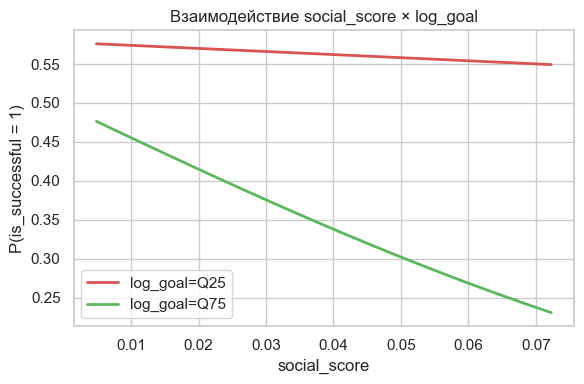

In [44]:
# Визуализация одного выбранного взаимодействия: social_score × log_goal
a, b = "social_score", "log_goal"
if a in df_fit.columns and b in df_fit.columns:
    grid_a = np.linspace(df_fit[a].quantile(0.05), df_fit[a].quantile(0.95), 30)
    b_lo = df_fit[b].quantile(0.25)
    b_hi = df_fit[b].quantile(0.75)

    feats = [f for f in FEATURE_SETS["C_all"] if f in df_fit.columns and f not in (a, b)]
    X = df_fit[feats + [a, b]].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    X[a] = center(X[a]); X[b] = center(X[b])
    X[f"{a}__x__{b}"] = X[a] * X[b]
    Xc = sm.add_constant(X, has_constant="add")
    m = sm.Logit(y, Xc).fit(disp=0, cov_type="HC1", maxiter=300)

    base = Xc.mean()
    fig, ax = plt.subplots(figsize=(6, 4))
    for b_val, lbl, color in [(b_lo - df_fit[b].mean(), f"{b}=Q25", "#d9534f"),
                              (b_hi - df_fit[b].mean(), f"{b}=Q75", "#5cb85c")]:
        preds = []
        for a_val in grid_a - df_fit[a].mean():
            row = base.copy()
            row[a] = a_val
            row[b] = b_val
            row[f"{a}__x__{b}"] = a_val * b_val
            preds.append(m.predict(row.to_frame().T).iloc[0])
        ax.plot(grid_a, preds, label=lbl, color=color, lw=2)
    ax.set_xlabel(a); ax.set_ylabel("P(is_successful = 1)")
    ax.set_title(f"Взаимодействие {a} × {b}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/interaction_{a}_x_{b}.png", dpi=120)
    plt.show()


## 23. Квантильная регрессия

OLS оценивает условное **среднее** `E[y | X]`. Квантильная регрессия (`sm.QuantReg`) — условные **квантили** `Q_τ(y | X)`. Это удобно, когда:

- распределение `funding_ratio` сильно скошено (хвост оверфандеров);
- интересует, как меняются предикторы для «плохих» (τ=0.1) и «хороших» (τ=0.9) проектов.

Бежим по квантилям τ ∈ {0.1, 0.25, 0.5, 0.75, 0.9} на непрерывном `funding_ratio` и смотрим, как коэффициенты меняются вдоль распределения.


In [45]:
# ═══ КОЛОНКИ МОДЕЛИ — Quantile Regression (τ ∈ {0.1, 0.25, 0.5, 0.75, 0.9}) ══
# Логика: цель — непрерывный log1p(funding_ratio). Берём компактный набор
# (без категорий и годов), чтобы коэффициенты по квантилям были сравнимы и
# видно было, как эффект ключевых фич меняется между провалами и оверфандерами.
# Колонки (QUANT_FEATURES):
#   log_goal, log_duration_days, log_text_length, has_video,
#   social_score, gratitude_score, we_ratio, i_ratio,
#   certainty_score, uncertainty_score,
#   number_density, readability_fog,
#   rubert_positive, rubert_negative
# ═════════════════════════════════════════════════════════════════════════════

from statsmodels.regression.quantile_regression import QuantReg

# Цель для квантильной регрессии — непрерывный log(1 + funding_ratio)
df_fit["log_funding_ratio"] = np.log1p(df_fit["funding_ratio"].clip(lower=0))

QUANT_FEATURES = [c for c in [
    "log_goal", "log_duration_days", "log_text_length", "has_video",
    "social_score", "gratitude_score", "we_ratio", "i_ratio",
    "certainty_score", "uncertainty_score",
    "number_density", "readability_fog",
    "rubert_positive", "rubert_negative",
] if c in df_fit.columns]

X_q = df_fit[QUANT_FEATURES].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
X_q = X_q.loc[:, X_q.nunique() > 1]
X_q = sm.add_constant(X_q, has_constant="add")
y_q = df_fit["log_funding_ratio"]

taus = [0.1, 0.25, 0.5, 0.75, 0.9]
quant_coefs = {}
for tau in taus:
    try:
        m = QuantReg(y_q, X_q).fit(q=tau, max_iter=2000)
        quant_coefs[tau] = m.params
    except Exception as e:
        print(f"tau={tau}: ошибка {e}")

coef_table = pd.DataFrame(quant_coefs).round(3)
print("Коэффициенты по квантилям:")
print(coef_table.to_string())

Коэффициенты по квантилям:
                    0.10   0.25   0.50   0.75   0.90
const              1.257  1.634  1.774  1.242  1.597
log_goal          -0.063 -0.059 -0.054 -0.024 -0.038
log_duration_days -0.005 -0.050 -0.069 -0.027 -0.045
log_text_length    0.024  0.014  0.011 -0.001  0.004
has_video          0.070  0.062  0.042  0.018  0.036
social_score      -4.227 -4.639 -3.724 -1.108 -1.475
gratitude_score    6.399  7.471  3.967  1.348  7.346
we_ratio           0.650  0.794  0.342  0.138  0.402
i_ratio            1.559  0.187 -1.066 -0.338 -0.888
certainty_score   -0.121  0.948 -0.545  0.636  3.095
uncertainty_score  3.339  2.735  4.955  2.241  4.783
number_density    -1.211 -1.223 -1.228 -0.361 -0.444
readability_fog   -0.005 -0.006 -0.006 -0.002 -0.003
rubert_positive   -0.578 -0.588 -0.302 -0.127 -0.256
rubert_negative   -0.735 -0.550 -0.231 -0.100 -0.217


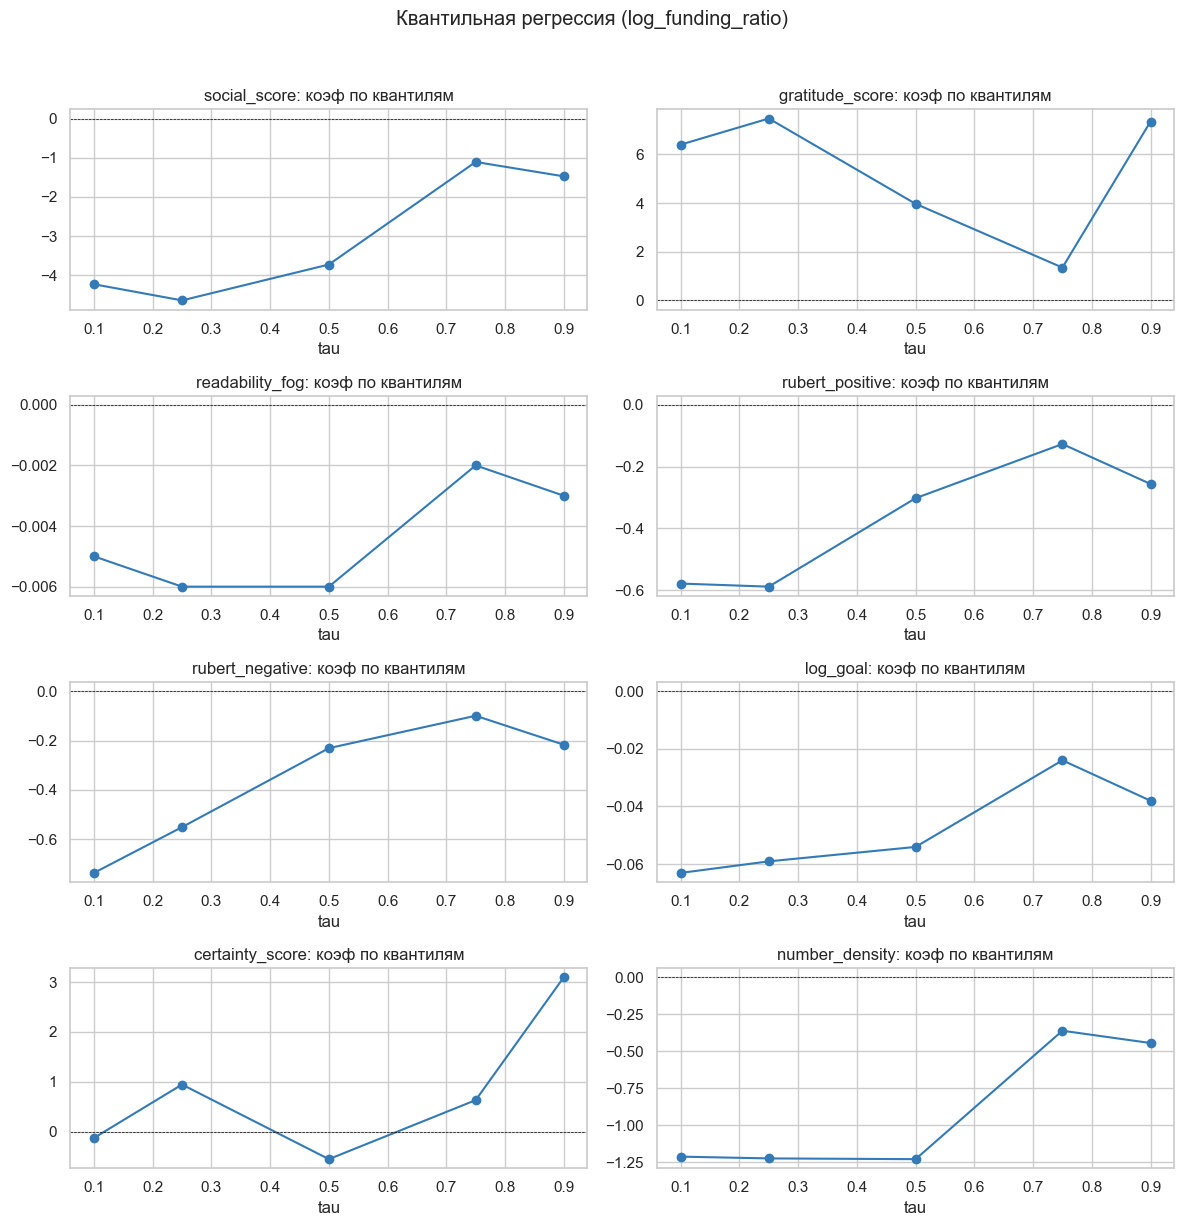

In [47]:
# Как коэффициенты движутся по квантилям для ключевых признаков
plot_feats = [c for c in ["social_score", "gratitude_score", "readability_fog",
                          "rubert_positive", "rubert_negative", "log_goal",
                          "certainty_score", "number_density"]
              if c in coef_table.index]

ncol = 2
nrow = int(np.ceil(len(plot_feats) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(6 * ncol, 3 * nrow))
for ax, f in zip(axes.flat, plot_feats):
    vals = coef_table.loc[f]
    ax.plot(vals.index, vals.values, marker="o", color="#337ab7")
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_title(f"{f}: коэф по квантилям")
    ax.set_xlabel("tau")
for ax in axes.flat[len(plot_feats):]:
    ax.axis("off")
plt.suptitle("Квантильная регрессия (log_funding_ratio)", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/quantile_coefs.png", dpi=120, bbox_inches="tight")
plt.show()

## 24. Two-part / Hurdle model

Распределение `funding_ratio` бимодальное: много провалов (< 1) и «хвост» оверфандеров. Моделировать его одним уравнением тяжело, потому что:

- нули (или полупровалы) — это **решение** донорского сообщества «не поддержать»;
- величина `funding_ratio` среди успешных — **интенсивность** поддержки, где механизмы могут быть другими.

Two-part модель разделяет эти процессы:

1. **Часть 1 (селекция)**
   `P(funding_ratio ≥ 1 | X)` — логит/пробит.
   По сути это `is_successful`, но оформляем заново, чтобы показать связку.

2. **Часть 2 (интенсивность)**
   Среди `funding_ratio ≥ 1`:
   `E[log(funding_ratio) | funding_ratio ≥ 1, X]` — OLS на лог-шкале.

Дополнительно смотрим две подгруппы:

- **Среди неуспешных** (`funding_ratio < 1`): что коррелирует с приближением к 1 (OLS на `funding_ratio` в [0, 1)).
- **Среди успешных** (`funding_ratio ≥ 1`): что связано с оверфандингом (OLS на `log(funding_ratio)`, где 0 ⇔ ровно 100%).


In [ ]:
# Подготовка: гарантируем, что funding_ratio и producer features на месте
df_fit["funding_ratio"] = df_fit["funding_ratio"].fillna(0).clip(lower=0)
df_fit["success_binary"] = (df_fit["funding_ratio"] >= 1).astype(int)

n_total = len(df_fit)
n_succ = int(df_fit["success_binary"].sum())
n_fail = n_total - n_succ
print(f"всего: {n_total}")
print(f"  funding_ratio < 1 : {n_fail} ({n_fail/n_total*100:.1f}%)")
print(f"  funding_ratio ≥ 1 : {n_succ} ({n_succ/n_total*100:.1f}%)")

# Визуализация логарифмов по подгруппам
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(df_fit.loc[df_fit["success_binary"] == 0, "funding_ratio"],
             bins=20, color="#d9534f", edgecolor="white")
axes[0].set_title("funding_ratio | < 1 (провалы)")
axes[0].set_xlabel("funding_ratio")

succ_vals = df_fit.loc[df_fit["success_binary"] == 1, "funding_ratio"]
axes[1].hist(np.log(succ_vals.clip(lower=1e-6)),
             bins=20, color="#5cb85c", edgecolor="white")
axes[1].set_title("log(funding_ratio) | ≥ 1 (успешные)")
axes[1].set_xlabel("log(funding_ratio)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/hurdle_distributions.png", dpi=120)
plt.show()


### 24.1 Часть 1 — селекция: `P(funding_ratio ≥ 1 | X)`

Логит на всех `n` наблюдениях. Набор признаков — `C_all` (контроли + категории + годы + текст).


In [ ]:
# ═══ КОЛОНКИ МОДЕЛИ — Hurdle · Part 1 (selection: P(funding_ratio ≥ 1)) ══════
# Логика: первая часть двухступенчатой модели — бинарный логит на всей выборке.
# Колонки: FEATURE_SETS["C_all"] — контроли + категории + годы + текст.
# ═════════════════════════════════════════════════════════════════════════════

def fit_hurdle_part1(df, feats, label="C_all"):
    X = df[feats].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")
    y = df["success_binary"].astype(int)
    if X.shape[1] >= len(y):
        print(f"[part1/{label}] пропуск: предикторов ({X.shape[1]}) ≥ наблюдений ({len(y)})")
        return None
    try:
        m = sm.Logit(y, X).fit(disp=0, cov_type="HC1", maxiter=300)
    except Exception as e:
        print(f"[part1/{label}] ошибка: {e}")
        return None
    print(f"\n══ Hurdle · Part 1 (selection) · {label} ══")
    print(f"  n={int(m.nobs)}  pseudo R²={m.prsquared:.3f}  AIC={m.aic:.1f}")
    summ = pd.DataFrame({
        "coef": m.params, "se": m.bse,
        "z": m.tvalues, "p": m.pvalues,
        "OR": np.exp(m.params),
    }).round(4)
    print(summ.sort_values("p").to_string())
    return m


feats_all = [f for f in FEATURE_SETS["C_all"] if f in df_fit.columns]
hurdle_part1 = fit_hurdle_part1(df_fit, feats_all, label="C_all")


### 24.2 Часть 2 — интенсивность среди успешных: `E[log(funding_ratio) | funding_ratio ≥ 1]`

OLS с HC1 на подвыборке `success_binary == 1`. Цель — `log(funding_ratio)`; 0 означает «ровно 100%», положительные значения — оверфандинг.


In [ ]:
# ═══ КОЛОНКИ МОДЕЛИ — Hurdle · Part 2 (intensity: log(funding_ratio) | ≥ 1) ══
# Логика: OLS c HC1 на подвыборке УСПЕШНЫХ — «что усиливает оверфандинг».
# Колонки: тот же FEATURE_SETS["C_all"], но с предупреждением — на подвыборке
# константные фичи автоматически отсеиваются в fit_hurdle_part2.
# ═════════════════════════════════════════════════════════════════════════════

def fit_hurdle_part2(df, feats, label="C_all"):
    sub = df[df["success_binary"] == 1].copy()
    sub["log_fr"] = np.log(sub["funding_ratio"].clip(lower=1e-6))

    X = sub[feats].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")
    y = sub["log_fr"].astype(float)

    if X.shape[1] >= len(y):
        print(f"[part2/{label}] пропуск: n_успешных ({len(y)}) слишком мало для {X.shape[1]} предикторов")
        return None
    try:
        m = sm.OLS(y, X).fit(cov_type="HC1")
    except Exception as e:
        print(f"[part2/{label}] ошибка: {e}")
        return None
    print(f"\n══ Hurdle · Part 2 (intensity | success) · {label} ══")
    print(f"  n={int(m.nobs)}  R²={m.rsquared:.3f}  adjR²={m.rsquared_adj:.3f}  AIC={m.aic:.1f}")
    summ = pd.DataFrame({
        "coef": m.params, "se": m.bse,
        "t": m.tvalues, "p": m.pvalues,
    }).round(4)
    print(summ.sort_values("p").to_string())
    return m


hurdle_part2 = fit_hurdle_part2(df_fit, feats_all, label="C_all")


### 24.3 Комбинированное безусловное ожидание

Two-part оценивает `E[y | X]` как произведение двух частей:

`E[y | X] = P(y ≥ 1 | X) · E[y | y ≥ 1, X]`

Здесь для наглядности считаем предсказанную ожидаемую `funding_ratio` на всей выборке по обеим частям, переводя лог-предсказание обратно в шкалу `funding_ratio` через `exp(·)`.


In [ ]:
if hurdle_part1 is not None and hurdle_part2 is not None:
    # Приводим матрицы признаков к колонкам, которые реально ушли в модели
    feats_p1 = [c for c in hurdle_part1.params.index if c != "const"]
    feats_p2 = [c for c in hurdle_part2.params.index if c != "const"]

    X1 = df_fit[feats_p1].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X1 = sm.add_constant(X1, has_constant="add")
    p_success = hurdle_part1.predict(X1)

    X2 = df_fit[feats_p2].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X2 = sm.add_constant(X2, has_constant="add")
    exp_log_fr = hurdle_part2.predict(X2)

    e_y = p_success * np.exp(exp_log_fr)

    cmp = pd.DataFrame({
        "funding_ratio":    df_fit["funding_ratio"],
        "E[y|X] hurdle":    e_y,
        "P(success|X)":     p_success,
        "E[log_fr|succ,X]": exp_log_fr,
    })
    print("Head:")
    print(cmp.head(10).round(3).to_string())
    print(f"\ncorr(actual, E[y|X]) = {cmp['funding_ratio'].corr(cmp['E[y|X] hurdle']):.3f}")

    plt.figure(figsize=(5, 5))
    plt.scatter(cmp["E[y|X] hurdle"], cmp["funding_ratio"],
                alpha=0.4, color="#337ab7")
    mx = max(cmp["E[y|X] hurdle"].max(), cmp["funding_ratio"].max())
    plt.plot([0, mx], [0, mx], color="black", lw=0.7, ls="--")
    plt.xlabel("E[y|X] из two-part модели")
    plt.ylabel("фактический funding_ratio")
    plt.title("Two-part: предсказание vs факт")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/hurdle_predict_vs_actual.png", dpi=120)
    plt.show()


### 24.4 Среди неуспешных: что связано с приближением к 1?

OLS на подвыборке `funding_ratio < 1` с целевой переменной `funding_ratio` (≈ «насколько далеко не дотянули»). Положительный коэффициент → признак помогает приблизиться к 100% даже при провале.


In [ ]:
# ═══ КОЛОНКИ МОДЕЛИ — «Среди неуспешных: приближение к 1» ════════════════════
# Логика: OLS c HC1 на подвыборке НЕ-успешных (funding_ratio < 1).
# Таргет — сам funding_ratio: «насколько проект не дотянул».
# Колонки: FEATURE_SETS["C_all"].
# ═════════════════════════════════════════════════════════════════════════════

def fit_failed_approach(df, feats, label="C_all"):
    sub = df[df["success_binary"] == 0].copy()
    if len(sub) < 10:
        print(f"[failed/{label}] пропуск: слишком мало неуспешных ({len(sub)})")
        return None

    X = sub[feats].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")
    y = sub["funding_ratio"].astype(float)

    if X.shape[1] >= len(y):
        print(f"[failed/{label}] пропуск: предикторов ({X.shape[1]}) ≥ наблюдений ({len(y)})")
        return None
    try:
        m = sm.OLS(y, X).fit(cov_type="HC1")
    except Exception as e:
        print(f"[failed/{label}] ошибка: {e}")
        return None
    print(f"\n══ Среди неуспешных · приближение к 1 · {label} ══")
    print(f"  n={int(m.nobs)}  R²={m.rsquared:.3f}  adjR²={m.rsquared_adj:.3f}")
    summ = pd.DataFrame({
        "coef": m.params, "se": m.bse,
        "t": m.tvalues, "p": m.pvalues,
    }).round(4)
    print(summ.sort_values("p").head(20).to_string())
    return m


failed_model = fit_failed_approach(df_fit, feats_all, label="C_all")


### 24.5 Среди успешных: что связано с оверфандингом?

OLS на подвыборке `funding_ratio ≥ 1` с `log(funding_ratio)` в качестве цели. В отличие от 24.2, здесь нас интересует именно знак и значимость коэффициентов — признаки «overfunding drivers».


In [ ]:
# ═══ КОЛОНКИ МОДЕЛИ — «Среди успешных: оверфандинг» ══════════════════════════
# Логика: OLS на подвыборке УСПЕШНЫХ с log(funding_ratio) как целью.
# Отвечает на вопрос «что связано со сбором сильно сверх 100%».
# Колонки: FEATURE_SETS["C_all"] (константные на подвыборке отсеиваются).
# ═════════════════════════════════════════════════════════════════════════════

def fit_overfunding(df, feats, label="C_all"):
    sub = df[df["success_binary"] == 1].copy()
    if len(sub) < 10:
        print(f"[over/{label}] пропуск: мало успешных ({len(sub)})")
        return None
    sub["log_fr"] = np.log(sub["funding_ratio"].clip(lower=1e-6))

    X = sub[feats].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")
    y = sub["log_fr"].astype(float)

    if X.shape[1] >= len(y):
        print(f"[over/{label}] пропуск: предикторов ({X.shape[1]}) ≥ наблюдений ({len(y)})")
        return None
    try:
        m = sm.OLS(y, X).fit(cov_type="HC1")
    except Exception as e:
        print(f"[over/{label}] ошибка: {e}")
        return None
    print(f"\n══ Среди успешных · overfunding · {label} ══")
    print(f"  n={int(m.nobs)}  R²={m.rsquared:.3f}  adjR²={m.rsquared_adj:.3f}")
    top = pd.DataFrame({
        "coef": m.params, "se": m.bse,
        "t": m.tvalues, "p": m.pvalues,
    }).round(4).sort_values("p")
    print(top.head(20).to_string())
    return m


overfund_model = fit_overfunding(df_fit, feats_all, label="C_all")


In [ ]:
# Сравнение коэффициентов: Part 1 (selection) vs Part 2 (intensity)
if hurdle_part1 is not None and hurdle_part2 is not None:
    common = [c for c in hurdle_part1.params.index
              if c in hurdle_part2.params.index and c != "const"]

    tbl = pd.DataFrame({
        "part1_coef":  hurdle_part1.params.loc[common],
        "part1_p":     hurdle_part1.pvalues.loc[common],
        "part2_coef":  hurdle_part2.params.loc[common],
        "part2_p":     hurdle_part2.pvalues.loc[common],
    }).round(3)
    print("Коэффициенты: Part 1 (selection, log-odds) vs Part 2 (intensity, log_fr):")
    print(tbl.to_string())

    plt.figure(figsize=(7, max(4, 0.3 * len(common))))
    idx = np.arange(len(common))
    plt.barh(idx - 0.2, tbl["part1_coef"], height=0.4,
             color="#337ab7", label="Part 1 (selection)")
    plt.barh(idx + 0.2, tbl["part2_coef"], height=0.4,
             color="#f0ad4e", label="Part 2 (intensity)")
    plt.yticks(idx, common)
    plt.axvline(0, color="black", lw=0.5)
    plt.legend()
    plt.title("Hurdle: коэффициенты селекции vs интенсивности")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/hurdle_coef_comparison.png", dpi=120)
    plt.show()


## 25. Модели с year fixed effects

Спецификация:

$y_i = \beta X_i + \delta_{\text{year}(i)} + \varepsilon_i$

где $\delta_{\text{year}}$ — дамми по году старта кампании (`YEAR_DUMMIES`, базовый год уже выкинут в секции производных признаков).

Годы контролируют макро-контекст: макроэкономика, рост платформы, изменения алгоритмов ранжирования. Без этих дамми временной тренд рискует просочиться в коэффициенты текстовых признаков.

**Что проверяем:** совместную значимость $\delta_{\text{year}}$
- для OLS → F-test;
- для Logit → Wald + likelihood ratio (LR).

Если тесты не отвергают `H₀: все δ_year = 0`, годовые эффекты можно не включать. Если отвергают — year FE существенны, интерпретируй `β` как «чистый» эффект признака при фиксированном годе.


In [ ]:
# # Проверяем, что YEAR_DUMMIES созданы и непустые
# if not YEAR_DUMMIES:
#     print("⚠ YEAR_DUMMIES пуст — вся выборка в одном году, year FE невозможны")
# else:
#     print(f"year dummies ({len(YEAR_DUMMIES)}): {YEAR_DUMMIES}")
#     print(f"базовый год: год с максимальной частотой в сэмпле")
#     print(df_fit[YEAR_DUMMIES].sum().astype(int).to_string())


### 25.1 OLS с year FE — непрерывная целевая `log(1 + funding_ratio)`

Сначала без годов (baseline), потом с годами. Потом F-test на совместную значимость `YEAR_DUMMIES`.


In [ ]:
# # ═══ КОЛОНКИ МОДЕЛИ — OLS с Year Fixed Effects ══════════════════════════════
# # Логика: проверяем, устойчивы ли коэффициенты к временным шокам (пандемия,
# # платформенные изменения). Сравниваем базовую модель (без годов) и модель с
# # YEAR_DUMMIES, F-test на совместную значимость годов.
# # Колонки:
# #   base_feats = FEATURE_SETS["C_all"] МИНУС YEAR_DUMMIES и start_year
# #                (чтобы не было коллинеарности с дамми);
# #   +YEAR_DUMMIES — во втором прогоне.
# # Цель: log1p(funding_ratio) (непрерывная).
# # ═════════════════════════════════════════════════════════════════════════════

# # Цель — непрерывная
# if "log_funding_ratio" not in df_fit.columns:
#     df_fit["log_funding_ratio"] = np.log1p(df_fit["funding_ratio"].clip(lower=0))

# # Набор контролей БЕЗ самой переменной start_year (иначе дамми + year = колинеарность)
# base_feats = [c for c in FEATURE_SETS["C_all"]
#               if c in df_fit.columns
#               and c not in YEAR_DUMMIES
#               and c != "start_year"]

# y_ols = df_fit["log_funding_ratio"].astype(float)


# def fit_ols_with(feats, label):
#     X = df_fit[feats].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
#     X = X.loc[:, X.nunique() > 1]
#     X = sm.add_constant(X, has_constant="add")
#     if X.shape[1] >= len(y_ols):
#         print(f"[OLS/{label}] пропуск: предикторов ({X.shape[1]}) ≥ наблюдений ({len(y_ols)})")
#         return None
#     return sm.OLS(y_ols, X).fit(cov_type="HC1")


# ols_no_yfe = fit_ols_with(base_feats, "без year FE")
# ols_yfe    = fit_ols_with(base_feats + YEAR_DUMMIES, "с year FE")

# if ols_no_yfe is not None and ols_yfe is not None:
#     print(f"\nOLS без year FE : n={int(ols_no_yfe.nobs)}  R²={ols_no_yfe.rsquared:.3f}  "
#           f"adjR²={ols_no_yfe.rsquared_adj:.3f}  AIC={ols_no_yfe.aic:.1f}")
#     print(f"OLS с year FE   : n={int(ols_yfe.nobs)}  R²={ols_yfe.rsquared:.3f}  "
#           f"adjR²={ols_yfe.rsquared_adj:.3f}  AIC={ols_yfe.aic:.1f}")


In [ ]:
# # ── F-test: совместная значимость всех year dummies в OLS ──
# if ols_yfe is not None and YEAR_DUMMIES:
#     year_in_model = [c for c in YEAR_DUMMIES if c in ols_yfe.params.index]
#     if year_in_model:
#         # Формируем гипотезу "каждый year dummy = 0"
#         hypotheses = ", ".join(f"{c} = 0" for c in year_in_model)
#         f_res = ols_yfe.f_test(hypotheses)
#         print("══ F-test: year FE = 0 (OLS) ══")
#         print(f"  F = {float(f_res.fvalue):.3f}")
#         print(f"  df = ({int(f_res.df_num)}, {int(f_res.df_denom)})")
#         print(f"  p-value = {float(f_res.pvalue):.4g}")
#         verdict = ("значимы → годы существенны, оставляем в модели"
#                    if float(f_res.pvalue) < 0.05
#                    else "не значимы → можно опустить year FE")
#         print(f"  Вывод: year FE {verdict}")
#     else:
#         print("ни один year dummy не остался в модели (мультиколлинеарность отфильтровала)")

#     # LR-тест: ML-версия аналогичного теста (сравнение вложенных моделей)
#     # F и LR для OLS эквивалентны в пределе, но посчитаем для справки
#     if ols_no_yfe is not None:
#         from scipy.stats import chi2
#         lr = 2 * (ols_yfe.llf - ols_no_yfe.llf)
#         df_diff = int(ols_yfe.df_model - ols_no_yfe.df_model)
#         p_lr = 1 - chi2.cdf(lr, df_diff) if df_diff > 0 else float("nan")
#         print(f"\nLR (OLS ML-эквивалент): LR = {lr:.3f}, df = {df_diff}, p = {p_lr:.4g}")


### 25.2 Logit с year FE — бинарная целевая `is_successful`

Та же логика: baseline без годов и модель с годами. Далее два теста на `H₀: все δ_year = 0`:

- **Wald-тест** — из одной только полной модели (асимптотический);
- **Likelihood-ratio test** — сравнение вложенных моделей (лучше в конечных выборках).


In [ ]:
# # ═══ КОЛОНКИ МОДЕЛИ — Logit с Year Fixed Effects ═════════════════════════════
# # Логика: та же проверка, что в OLS-ячейке, но для бинарной цели is_successful.
# # Тесты Wald и LR на совместную значимость всех year-dummies.
# # Колонки:
# #   base_feats (см. OLS year FE выше) — без YEAR_DUMMIES и start_year;
# #   base_feats + YEAR_DUMMIES — во втором прогоне.
# # ═════════════════════════════════════════════════════════════════════════════

# y_logit = df_fit[TARGET_COL].astype(int)


# def fit_logit_with(feats, label):
#     X = df_fit[feats].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
#     X = X.loc[:, X.nunique() > 1]
#     X = sm.add_constant(X, has_constant="add")
#     if X.shape[1] >= len(y_logit):
#         print(f"[Logit/{label}] пропуск: предикторов ({X.shape[1]}) ≥ наблюдений ({len(y_logit)})")
#         return None
#     try:
#         return sm.Logit(y_logit, X).fit(disp=0, cov_type="HC1", maxiter=300)
#     except Exception as e:
#         print(f"[Logit/{label}] ошибка: {e}")
#         return None


# logit_no_yfe = fit_logit_with(base_feats, "без year FE")
# logit_yfe    = fit_logit_with(base_feats + YEAR_DUMMIES, "с year FE")

# if logit_no_yfe is not None and logit_yfe is not None:
#     print(f"\nLogit без year FE : n={int(logit_no_yfe.nobs)}  "
#           f"pseudo R²={logit_no_yfe.prsquared:.3f}  AIC={logit_no_yfe.aic:.1f}  LLF={logit_no_yfe.llf:.2f}")
#     print(f"Logit с year FE   : n={int(logit_yfe.nobs)}  "
#           f"pseudo R²={logit_yfe.prsquared:.3f}  AIC={logit_yfe.aic:.1f}  LLF={logit_yfe.llf:.2f}")


In [ ]:
# # ── Wald и LR тесты: совместная значимость year FE ──
# from scipy.stats import chi2

# if logit_yfe is not None and YEAR_DUMMIES:
#     year_in_model = [c for c in YEAR_DUMMIES if c in logit_yfe.params.index]

#     if year_in_model:
#         hypotheses = ", ".join(f"{c} = 0" for c in year_in_model)
#         w = logit_yfe.wald_test(hypotheses, scalar=False)
#         print("══ Wald-тест: year FE = 0 (Logit) ══")
#         print(f"  chi² = {float(w.statistic):.3f}")
#         print(f"  df = {int(w.df_denom)}")
#         print(f"  p-value = {float(w.pvalue):.4g}")

#     if logit_no_yfe is not None:
#         lr = 2 * (logit_yfe.llf - logit_no_yfe.llf)
#         df_diff = int(logit_yfe.df_model - logit_no_yfe.df_model)
#         p_lr = 1 - chi2.cdf(lr, df_diff) if df_diff > 0 else float("nan")
#         print("\n══ LR-тест: year FE = 0 (Logit, вложенные модели) ══")
#         print(f"  LR = {lr:.3f}")
#         print(f"  df = {df_diff}")
#         print(f"  p-value = {p_lr:.4g}")

#         verdict = ("значимы → держим в модели"
#                    if p_lr < 0.05 else "не значимы → можно опустить")
#         print(f"  Вывод: year FE {verdict}")


In [ ]:
# # Визуализация коэффициентов при year dummies
# fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# if ols_yfe is not None:
#     ys = [c for c in YEAR_DUMMIES if c in ols_yfe.params.index]
#     vals = ols_yfe.params.loc[ys]
#     errs = ols_yfe.bse.loc[ys] * 1.96
#     axes[0].bar(range(len(ys)), vals.values, yerr=errs.values,
#                 color="#337ab7", alpha=0.85)
#     axes[0].set_xticks(range(len(ys)))
#     axes[0].set_xticklabels(ys, rotation=45, ha="right")
#     axes[0].axhline(0, color="black", lw=0.5)
#     axes[0].set_title("OLS: year FE (log_funding_ratio)")
#     axes[0].set_ylabel("δ_year (vs базовый)")

# if logit_yfe is not None:
#     ys = [c for c in YEAR_DUMMIES if c in logit_yfe.params.index]
#     vals = logit_yfe.params.loc[ys]
#     errs = logit_yfe.bse.loc[ys] * 1.96
#     axes[1].bar(range(len(ys)), vals.values, yerr=errs.values,
#                 color="#f0ad4e", alpha=0.85)
#     axes[1].set_xticks(range(len(ys)))
#     axes[1].set_xticklabels(ys, rotation=45, ha="right")
#     axes[1].axhline(0, color="black", lw=0.5)
#     axes[1].set_title("Logit: year FE (log-odds of success)")
#     axes[1].set_ylabel("δ_year (log-odds, vs базовый)")

# plt.tight_layout()
# plt.savefig(f"{FIG_DIR}/year_fixed_effects.png", dpi=120)
# plt.show()


Бинарная успешность — основной таргет:                                                                                          
                                                            
$y_i = \mathbf{I}\left[\frac{\text{collected}_i}{\text{target}_i} \geq 1\right]$                                          
                                                            
  Трёхуровневая успешность (funding_bucket) делит кампании по степени выполнения цели:                                            
                                              

$$\text{bucket}_i = \begin{cases} 0 & \text{если } r_i < 0{,}5 & \text{(провал)} \\ 1 & \text{если } 0{,}5 \leq r_i < 1{,}0 & \text{(частичный успех)} \\ 2 & \text{если } r_i \geq 1{,}0 & \text{(полный сбор)} \end{cases}$$
